In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import random
from scipy import optimize
from scipy import special

"""General Purpose Plotter
Curated T Dependence Data for film stress paper
"""


def Crowley_Q_int_FitAlternate(T, Q_TLS0, D, Beta1, Beta2, A_QP, T_c, Q_Other):
    """Temperature dependent Q_int fit from disentangling losses in tantalum superconducting circuits"""
    #setting constants
    hbar = 6.626070e-34
    Kb = 1.380649e-23
    f = 5.816561e9 #Res1 from no jumper sample
    w = 2*np.pi * f
    gap = 1.764*Kb*T_c
    n = 5e4
    Q_TLS = Q_TLS0 * np.sqrt(1 + (n**Beta1 / D*T**Beta2) * np.tanh((hbar*w)/(2*Kb*T)))/np.tanh((hbar*w)/(2*Kb*T))
    Q_QP = A_QP * (np.exp(gap/(Kb*T_c)) / (np.sinh((hbar*w)/(2*Kb*T)) * special.k0((hbar*w)/(2*Kb*T))))
    return (1/Q_TLS + 1/Q_QP + 1/Q_Other)**-1

def Crowley_Q_int_Fit(T, Q_TLS0, D, Beta1, Beta2, A_QP, T_c, Q_Other):
    """Temperature dependent Q_int fit from disentangling losses in tantalum superconducting circuits"""
    return (1/(Q_TLS0 * np.sqrt(1 + (n**Beta1 / D*T**Beta2) * np.tanh((hbar*w)/(2*Kb*T)))/np.tanh((hbar*w)/(2*Kb*T))) + 1/(A_QP * (np.exp(gap/(Kb*T_c)) / (np.sinh((hbar*w)/(2*Kb*T)) * special.k0((hbar*w)/(2*Kb*T))))) + 1/Q_Other)**-1

def Crowley_Q_int_FitAlternateQPOnly(T, Q_TLS0, D, Beta1, Beta2, A_QP, T_c, Q_Other):
    """Temperature dependent Q_int fit from disentangling losses in tantalum superconducting circuits"""
    #setting constants
    hbar = 6.626070e-34
    Kb = 1.380649e-23
    f = 5.816561e9 #Res1 from no jumper sample
    w = 2*np.pi * f
    gap = 1.764*Kb*T_c
    n = 5e4
    Q_TLS = Q_TLS0 * np.sqrt(1 + (n**Beta1 / D*T**Beta2) * np.tanh((hbar*w)/(2*Kb*T)))/np.tanh((hbar*w)/(2*Kb*T))
    Q_QP = A_QP * (np.exp(gap/(Kb*T_c)) / (np.sinh((hbar*w)/(2*Kb*T)) * special.k0((hbar*w)/(2*Kb*T))))
    return Q_QP

def Crowley_Q_int_FitQPOnly(T, Q_TLS0, D, Beta1, Beta2, A_QP, T_c, Q_Other):
    """Temperature dependent Q_int fit from disentangling losses in tantalum superconducting circuits"""
    return A_QP * (np.exp(gap/(Kb*T_c)) / (np.sinh((hbar*w)/(2*Kb*T)) * special.k0((hbar*w)/(2*Kb*T))))




#Class initialization
class LossPlotter:
    def __init__(self):
        
        self.ColorList = ['red', 'orange', 'gold','green', 'blue', 'indigo','violet', 'cyan', 'brown', 'black', 'lightseagreen','coral', 'purple', 'seagreen', 'springgreen', 'aquamarine', 'mediumslateblue']
        self.MarkerSize = 14 #size of plot points
        self.CapSize = 14 #size of errorbar caps
        self.ErrLineWidth= 3 #thickness of errobars

        self.LeftSet = 0.125  # the left side of the subplots of the figure. Default is 0.125
        self.RightSet = 0.9   # the right side of the subplots of the figure. Default is 0.9
        self.BottomSet = 0.19  # the bottom of the subplots of the figure. Default is 0.1
        self.TopSet = 0.9     # the top of the subplots of the figure. Default is 0.9

        self.XTickNum = 15 #Number of x ticks
        self.XTickSize = 30 #Fontsize of x tick labels
        self.XPad = 20 #distance between x ticks and labels
        self.XLabelSize = 36 #size of the x axis label

        self.YTickSize = 30 #Fontsize of y tick labels.
        self.YPad = 0 #distance between y ticks and labels
        self.YLabelSize = 36 #size of the y axis label
        self.LegendSize = 20

        self.TitleSize = 40 #size of the plot title

    def BeginFigure(self, FigureName): #FigureName is the name of your figure.
        #plt.clf()
        self.PlotTitle =FigureName
        self.fig,self.ax = plt.subplots()
        plt.subplots_adjust(left = self.LeftSet, right = self.RightSet, bottom=self.BottomSet, top = self.TopSet)
    
    def GenericPlot(self, y,err,x, Xlabel, Ylabel, LineLabel, Color): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        self.ax.errorbar(x, y, yerr=err, fmt='o', ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])

        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel(Xlabel, fontsize = self.XLabelSize)
        self.ax.set_ylabel(Ylabel, fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        #self.ax.set_ylim(bottom=8)

    def PlotLoss(self, Qi_arr,QiErr_arr,np_arr, power10, LineLabel, Color): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        Qi_arr = Qi_arr * 10**power10
        QiErr_arr = 10**power10 * QiErr_arr / Qi_arr**2
        self.ax.semilogx(np_arr, 1/Qi_arr, 'o-')
        self.ax.errorbar(np_arr, 1/Qi_arr, yerr=QiErr_arr, fmt='o-', ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xscale = 'log'
        self.ax.yscale = 'log'
        self.ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=self.XTickNum, subs = 'auto'))
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, numticks=self.XTickNum))
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=3, length=14,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=2, length=8, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('$n_{p}$', fontsize = self.XLabelSize)
        self.ax.set_ylabel(r'1/$Q_{i}$  $(10^{power})$'.replace('power', str(power10)), fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotTempLoss(self, Qi_arr,QiErr_arr,np_arr, power10, LineLabel, Color, Format = 'o-', TOffset = 0): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        QiErr_arr = QiErr_arr / Qi_arr + QiErr_arr[0] /Qi_arr[0]
        Qi_arr = Qi_arr /Qi_arr[0]
        
        #print(QiErr_arr)
        #print(QiErr_arr / Qi_arr)
        #print(QiErr_arr[0] /Qi_arr[0])
        
        self.ax.plot(np_arr, Qi_arr, Format)
        self.ax.errorbar(np_arr, Qi_arr, yerr=QiErr_arr, fmt=Format, ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('$Temperature (mK)$', fontsize = self.XLabelSize)
        self.ax.set_ylabel('$Q_i/Q_{i0}$', fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        #self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotQiVsStress(self, Qi_arr,QiErr_arr,temp_arr, temp_point, stress, power10, LineLabel, Color, Format = 'o-', TOffset = 0, VarianceInteger = 0): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        if NormalizeStress == 1:
          QiErr_arr = QiErr_arr / Qi_arr + QiErr_arr[0] /Qi_arr[0]
          Qi_arr = Qi_arr /Qi_arr[0]

        #Qi_arr = Qi_arr * 10**power10
        #QiErr_arr = 10**power10 * QiErr_arr / Qi_arr**2

      
        
        diff_arr = np.absolute(temp_arr - temp_point)
        index = diff_arr.argmin()
        print("Difference Array:")
        print(diff_arr)
        print("Index:")
        print(index)
        print("Targeted Temperature:")
        print(temp_arr[index])
        print("Resultant Qi")
        print(Qi_arr[index])
        print("Test Qi_Arr")
        print(Qi_arr)
        
        if np.absolute(temp_point - temp_arr[index]) >= 100:
          print("Discovered point is too divergent from target temp! Scrapping datapoint")
          print(np.absolute(temp_point - temp_arr[index]))
          return
        
        if QiErr_arr[index] >= 0.5*Qi_arr[index]:
          print("Error bars too large! eliminating point")
          print(str(QiErr_arr[index]) + "," + str(Qi_arr[index]))
          return
        
        temp_arr = temp_arr + TOffset
        
        self.ax.errorbar(stress+VarianceInteger, Qi_arr[index], yerr=QiErr_arr[index], fmt=Format, ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('Stress (MPa)', fontsize = self.XLabelSize)
        self.ax.set_ylabel(r'$Q_{i}$  $(10^{power})$'.replace('power', str(power10)), fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        if NormalizeStress == 1:
          self.ax.set_ylabel('$Q_i/Q_{i0}$', fontsize = self.YLabelSize)
        self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotFreqVsStress(self, Freq_arr,temp_arr, temp_point, stress, power10, LineLabel, Color, Format = 'o-', TOffset = 0, VariableOffset = 0): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color

        #Qi_arr = Qi_arr * 10**power10
        #QiErr_arr = 10**power10 * QiErr_arr / Qi_arr**2

        Freq_arr = Freq_arr /Freq_arr[0]
        
        diff_arr = np.absolute(temp_arr - temp_point)
        index = diff_arr.argmin()
        print("Difference Array:")
        print(diff_arr)
        print("Index:")
        print(index)
        print("Targeted Temperature:")
        print(temp_arr[index])
        print("Resultant FreqShift")
        print(Freq_arr[index])
        print("Test FreqShift Arr")
        print(Freq_arr)
        
        if np.absolute(temp_point - temp_arr[index]) >= 100:
          print("Discovered point is too divergent from target temp! Scrapping datapoint")
          print(np.absolute(temp_point - temp_arr[index]))
          return

        temp_arr = temp_arr + TOffset
        
        self.ax.errorbar(stress+VariableOffset, Freq_arr[index], yerr=0, fmt=Format, ms=self.MarkerSize, capsize=0, elinewidth = 0, label=LineLabel, color = self.ColorList[Color])
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize*0.8, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize*0.8, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('Stress (MPa)', fontsize = self.XLabelSize)
        self.ax.set_ylabel('$\delta f/f_{0}$', fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotTempLossNonNormal(self, Qi_arr,QiErr_arr,np_arr, power10, LineLabel, Color, Format = 'o-', TOffset = 0): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        #QiErr_arr = QiErr_arr / Qi_arr + QiErr_arr[0] /Qi_arr[0]
        #Qi_arr = Qi_arr /Qi_arr[0]
        
        #print(QiErr_arr)
        #print(QiErr_arr / Qi_arr)
        #print(QiErr_arr[0] /Qi_arr[0])
        
        #self.ax.plot(np_arr, Qi_arr, 'o-')
        np_arr = np_arr + TOffset
        self.ax.errorbar(np_arr, Qi_arr, yerr=QiErr_arr, fmt=Format, ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('Temperature (mK)', fontsize = self.XLabelSize)
        self.ax.set_ylabel(r'$Q_{i}$  $(10^{power})$'.replace('power', str(power10)), fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        #self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotFreqShift(self, Qi_arr,np_arr, power10, LineLabel, Color, Format = 'o-', TOffset = 0): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        QiErr_arr = Qi_arr * 0.0
        #print("QiErrArrTest")
        #print(QiErr_arr)
        Qi_arr = Qi_arr /Qi_arr[0]
        #print(np_arr)
        #print(Qi_arr)
        #print(QiErr_arr)
        self.ax.plot(np_arr, Qi_arr, 'o-')
        self.ax.errorbar(np_arr, Qi_arr, QiErr_arr, fmt=Format, ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        #self.ax.errorbar(np_arr, Qi_arr, yerr=QiErr_arr, fmt='o-', ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=2, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize*0.75, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize*0.75, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('Temperature (mK)', fontsize = self.XLabelSize)
        self.ax.set_ylabel('$f/f_{0}$', fontsize = self.YLabelSize)  #Note: does not automatically update with power of 10.
        #self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def PlotTimeLoss(self, Qi_arr,QiErr_arr,time_arr, power10, LineLabel, Color, Normalize = False): #input your data, what power of 10 to multiply it by for the yaxis, a label for the legend, and a color
        Qi_arr = Qi_arr[Qi_arr != 0]
        QiErr_arr = QiErr_arr[QiErr_arr != 0]
        time_arr = time_arr[time_arr != 0]
        Qi_arr = Qi_arr * 10**-power10
        Qi_Avg = np.average(Qi_arr)
        QiErr_arr = QiErr_arr *10**-power10
        yaxisstr = '$Q_i/Q_{i0}$'
        if Normalize is True:
            QiErrPercent = QiErr_arr/Qi_arr
            Qi_arr = Qi_arr/Qi_Avg
            QiErr_arr = Qi_arr*QiErrPercent
            #QiErr_arr = QiErr_arr*10**-power10 / Qi_arr**2
            yaxisstr = '$Q_i/⟨Q_i⟩$'
            
        self.ax.plot(time_arr, Qi_arr, 'o')
        self.ax.errorbar(time_arr, Qi_arr, yerr=QiErr_arr, fmt='o', ms=self.MarkerSize, capsize=self.CapSize, elinewidth = self.ErrLineWidth, label=LineLabel, color = self.ColorList[Color])
        self.ax.xscale = 'log'
        self.ax.yscale = 'log'
        self.ax.xaxis.set_major_locator(ticker.AutoLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        self.ax.tick_params(axis = 'x', which = 'minor', labelsize =self.XTickSize, width=3, length=8,direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'x', which = 'major', labelsize =self.XTickSize, width=3, length=14, direction = 'in', top = True, pad = self.XPad)
        self.ax.tick_params(axis = 'y', which = 'major', labelsize =self.YTickSize, width=3, length=14, direction = 'in', right = True, pad = self.YPad)
        self.ax.tick_params(axis = 'y', which = 'minor', labelsize =self.YTickSize, width=2, length=8, direction = 'in', right = True, pad =self.YPad)
        self.ax.set_xlabel('$Time (s)$', fontsize = self.XLabelSize)
        self.ax.set_ylabel(r'$Q_{i}$  $(10^{power})$'.replace('power', str(power10)), fontsize = self.YLabelSize) #Note: does not automatically update with power of 10.
        if Normalize is True:
            self.ax.set_ylabel('$Q_i/⟨Q_i⟩$', fontsize = self.YLabelSize)
        #self.ax.set_title(self.PlotTitle, fontsize = self.TitleSize)
        self.ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)

    def DisplayFigure(self, LegendBool): #Display the data, with or without a legend
        if LegendBool is True:
            plt.legend(fontsize = 20)
        plt.show()

    def FindRolloff(self, Qi_arr,temp_arr):
        Qi_max = np.max(Qi_arr) #find Qi_max
        Qi_halfmax = Qi_max/2 #find half max
        Stop_point = Qi_halfmax
        #print("stopping at: " + str(Stop_point))
        #find rolloff index and values
        i = 1
        #print(Qi_arr)
        temp_stop = 0
        while i < len(Qi_arr):
            if Qi_arr[i] < Stop_point and Qi_arr[i - 1] > Stop_point:
                #print("Located index in Qi:")
                #print(i, Qi_arr[i-1], Qi_halfmax, Qi_arr[i])
                #perform a rudimentary interpolation between the two points
                distance_bef = Qi_arr[i-1] - Stop_point
                distance_total = Qi_arr[i-1] - Qi_arr[i]
                distance_percentage = distance_bef/distance_total
                #print(distance_percentage)
                #apply the same distance to temperature
                temp_dist_total = temp_arr[i] - temp_arr[i-1]
                #print(temp_dist_total)
                temp_stop = temp_arr[i-1] + temp_dist_total*distance_percentage
                #print(i, temp_arr[i-1], temp_halfmax, temp_arr[i])
            i=i+1
        return Qi_max,temp_stop



    def BoxPlotter(CombinedData, Labels, Length, Title):

        fig, ax = plt.subplots()
        ax.boxplot(CombinedData, whis=0, widths = 0.25, boxprops = dict(linewidth=2), medianprops = dict(linewidth=2, color ='purple'))

        ax.tick_params(axis = 'x', which = 'minor', labelsize =46, width=3, length=14,direction = 'in', top = True, pad = 0)
        ax.tick_params(axis = 'x', which = 'major', labelsize =46, width=2, length=8, direction = 'in', top = True, pad = 0)
        #ax.tick_params(axis = 'y', which = 'minor', labelsize =20, width=3, length=6)
        ax.tick_params(axis = 'y', which = 'major', labelsize =36, width=3, length=14, direction = 'in', right = True)
        ax.tick_params(axis = 'y', which = 'minor', labelsize =36, width=2, length=8, direction = 'in', right = True)
        ax.set_ylabel('1/$Q_{i}$  $(10^{-6})$', fontsize = 46)
        #ax.set_xlabel(Labels)
        ax.set_xticklabels(Labels, rotation = 0, fontsize = 30)
        ax.yaxis.set_minor_locator(ticker.AutoLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.set_title(Title, fontsize = 20)
        ax.ticklabel_format(axis ='y', style = 'plain', scilimits=(0,0), useOffset = False)
lp = LossPlotter() #class initialization

SU_Nb_2mTorrRes1_Qi = np.array([3.50e+04,3.70e+04,3.44e+04,3.30e+04,3.21e+04,2.98e+04,2.37e+04,1.57e+04,
 1.78e+04,1.91e+04,1.83e+04,1.77e+04,1.34e+04,1.13e+04,1.11e+04,9.08e+03,
 6.76e+03,3.73e+03,5.37e+03,1.60e+04,3.44e-01,3.70e+02])
SU_Nb_2mTorrRes1_QiErr = np.array([  354.62,  414.47,  392.69,  372.1 ,  356.74,  401.05,  347.82,  305.37,
   284.29,  274.46,  300.84,  314.85,  269.88,  236.14,  255.9 ,  231.36,
   232.86,  190.16,  489.61,23672.  ,  948.44,  426.45])
SU_Nb_2mTorrRes1_Temp = np.array([ 100.25, 200.29, 300.75, 399.11, 503.65, 602.46, 702.72, 809.61, 901.78,
 1009.8 ,1082.62,1164.32,1238.47,1316.68,1397.1 ,1504.27,1723.49,1921.06,
 2114.98,2270.99,2447.57,2680.24])
SU_Nb_2mTorrRes2_Qi = np.array([135725.18,132472.73,128289.18,124273.05,123270.17,123028.68,118872.86,
 112613.54, 96793.86, 85999.  , 78831.54, 68876.69, 60865.44, 58302.05,
  51689.93, 42832.88, 30396.69, 24582.1 , 19051.47, 14030.93, 11760.48,
   7484.47])
SU_Nb_2mTorrRes2_QiErr = np.array([1428.97,1697.78,1618.79,1434.71,1348.88,1414.25,1372.64,1434.47,1316.49,
 1336.69,1136.04,1429.31,1070.93,1099.93, 975.1 , 922.14, 747.31, 679.73,
  638.3 , 518.22, 526.65, 362.01])
SU_Nb_2mTorrRes2_Temp = np.array([ 100.19, 199.87, 299.64, 400.34, 497.25, 595.87, 703.27, 800.25, 907.47,
 1006.83,1084.66,1161.23,1243.74,1297.12,1397.11,1490.49,1738.53,1946.12,
 2124.69,2299.77,2497.4 ,2698.87])
SU_Nb_2mTorrRes3_Qi = np.array([131329.28,117959.33,114144.87,112116.65,107501.15,103293.74,103494.86,
  95313.5 , 87584.91, 81312.35, 72674.11, 62681.29, 56781.16, 57575.47,
  49600.29, 43572.88, 30129.99, 26781.22, 21413.92, 16764.7 , 11500.01,
   6324.78])
SU_Nb_2mTorrRes3_QiErr = np.array([1138.08, 933.38, 927.97,1015.03, 979.12, 886.34,1102.5 , 891.65, 816.01,
  803.68, 741.64, 793.46, 666.65, 738.46, 695.86, 642.58, 526.58, 612.41,
  552.38, 507.11, 400.9 , 268.31])
SU_Nb_2mTorrRes3_Temp = np.array([ 100.12, 200.25, 299.36, 398.59, 496.97, 601.84, 701.85, 798.78, 903.65,
  998.73,1086.67,1146.69,1240.2 ,1294.24,1391.71,1511.96,1721.67,1937.77,
 2090.44,2290.95,2467.78,2699.19])
SU_Nb_2mTorrRes4_Qi = np.array([77463.55,60564.73,70361.21,65438.62,63856.89,61157.16,75760.15,63767.27,
 64725.74,56062.62,58410.75,50356.05,46562.99,39021.6 ,37619.25,34433.49,
 26800.59,23172.29,17382.53,13464.95,10390.94, 8771.37])
SU_Nb_2mTorrRes4_QiErr = np.array([1370.5 ,1412.67,1219.48,1315.78,1321.53,1517.95,1315.19,1089.86,1159.76,
 1065.96,1124.51, 986.39,1053.52, 851.03, 850.62, 835.59, 762.13, 876.23,
  673.79, 867.17, 581.64, 683.58])
SU_Nb_2mTorrRes4_Temp = np.array([ 100.16, 200.48, 300.43, 399.73, 500.45, 597.72, 704.68, 802.46, 903.2 ,
 1009.2 ,1079.27,1165.82,1240.2 ,1294.27,1397.18,1491.6 ,1736.7 ,1933.48,
 2119.75,2282.58,2483.98,2683.54])

SU_Nb_10mTorrRes1_Qi = np.array([1575359.13,1628087.69,1640789.05,1713334.34,1729884.45,1709353.16,
 1683082.91,1660783.87,1656131.13,1652118.51,1632477.12,1404038.21,
 1245997.68,1197166.47,1077954.95, 890265.84, 472823.63, 253517.13,
  128915.99,  64601.01,  44059.09,  21539.82])
SU_Nb_10mTorrRes1_QiErr = np.array([3413.  ,4200.17,4300.18,3355.75,4104.44,3833.9 ,3970.5 ,3743.64,3675.4 ,
 2952.81,3353.64,3261.79,2768.42,2885.81,2617.41,2517.88,1607.41,1336.24,
  895.72, 650.84, 452.75, 258.02])
SU_Nb_10mTorrRes1_Temp = np.array([ 100.32, 200.1 , 299.87, 398.76, 503.79, 603.92, 702.41, 803.99, 897.57,
 1003.95,1088.72,1174.47,1242.86,1314.58,1400.47,1500.43,1711.65,1859.47,
 2045.44,2290.83,2457.37,2671.3 ])
SU_Nb_10mTorrRes2_Qi = np.array([2213141.83,2396589.4 ,2542740.85,2547619.36,2456352.03,2456426.98,
 2455195.43,2450035.86,2337115.11,2385075.26,2268362.85,2028734.16,
 1761263.28,1607819.54,1397579.19,1055948.61, 461038.84, 225008.94,
  109328.39,  52904.91,  32261.76,  18114.4 ])
SU_Nb_10mTorrRes2_QiErr = np.array([4636.84,4145.03,4286.43,3435.46,3205.77,2879.95,3045.34,4021.34,4066.36,
 4191.69,2881.06,2227.82,3244.71,2739.13,2048.97,1895.69,1350.52,1518.53,
 1283.56, 659.34, 323.4 , 229.53])
SU_Nb_10mTorrRes2_Temp = np.array([ 100.26, 200.25, 299.82, 401.14, 497.7 , 601.22, 701.55, 796.95, 898.5 ,
 1000.49,1094.28,1173.72,1239.33,1312.63,1397.22,1487.82,1720.01,1898.97,
 2038.46,2276.63,2451.24,2686.97])
SU_Nb_10mTorrRes3_Qi = np.array([3727471.43,4430075.51,4841549.85,5041977.57,5174491.08,5258470.9 ,
 5284227.18,5173960.02,5074267.88,4870683.48,4438791.49,3519982.82,
 2409681.7 ,2119292.44,1676493.8 ,1149993.68, 434815.02, 196974.43,
  107996.42,  55290.7 ,  33760.47,  20768.39])
SU_Nb_10mTorrRes3_QiErr = np.array([ 9182.65, 8979.44,14210.42,11893.54, 6277.94, 9709.34, 5186.33, 3525.84,
  3637.84, 3754.09, 3249.43, 3100.16, 2226.36, 1853.19, 1527.02, 1233.14,
   790.24,  562.62,  349.79,  340.21,  234.43,  164.89])
SU_Nb_10mTorrRes3_Temp = np.array([ 100.03, 199.62, 299.59, 399.64, 501.5 , 599.97, 701.86, 799.52, 904.59,
 1003.37,1081.99,1158.11,1241.96,1307.78,1402.66,1499.27,1723.33,1943.94,
 2080.92,2262.69,2460.99,2715.04])
SU_Nb_10mTorrRes4_Qi = np.array([3308031.13,3580410.61,4061482.58,4408708.85,4352699.58,4516951.25,
 4516557.33,4538185.46,4482688.55,4350614.08,4054121.65,3263160.96,
 2301325.04,2026451.72,1615211.66,1098556.66, 417520.23, 181690.5 ,
   96770.67,  48346.53,  26473.8 ,  18055.  ])
SU_Nb_10mTorrRes4_QiErr = np.array([4803.65,8715.95,5493.  ,9608.81,8876.05,6584.91,5418.35,6063.34,4858.8 ,
 4015.68,3954.29,3338.18,2533.43,2203.87,1853.87,2044.39, 819.8 , 530.85,
  427.58, 307.22, 239.32, 201.24])
SU_Nb_10mTorrRes4_Temp = np.array([ 100.08, 200.11, 300.15, 400.61, 499.01, 601.01, 701.27, 800.98, 902.24,
 1007.45,1080.62,1157.36,1246.4 ,1315.7 ,1406.04,1508.1 ,1723.24,1925.24,
 2064.63,2273.76,2494.25,2710.41])

SU_Nb_2mTorr_FreqRes1_Freq = np.array([4.72799976e+09,4.72799061e+09,4.72797788e+09,4.72797503e+09,
 4.72795631e+09,4.72791270e+09,4.72784596e+09,4.72783634e+09,
 4.72770781e+09,4.72748941e+09,4.72744360e+09,4.72723268e+09,
 4.72706391e+09,4.72680176e+09,4.72630907e+09,4.72577511e+09,
 4.72406360e+09,4.72215289e+09,4.71906316e+09,4.72794488e+09,
 4.72981320e+09,4.73645680e+09])
SU_Nb_2mTorr_FreqRes1_Temp = np.array([ 100.2539287988, 200.2907952681, 300.7526274938, 399.1105708774,
  503.6478085885, 602.4573724633, 702.7216984881, 809.6089616037,
  901.7755530001,1009.7986782999,1082.6170837053,1164.3161863325,
 1238.4730181229,1316.6770853443,1397.0979426784,1504.2654501037,
 1723.4880717902,1921.056631987 ,2114.9765016194,2270.9893463639,
 2447.5719958298,2680.2371801602])
SU_Nb_2mTorr_FreqRes2_Freq = np.array([5.45684444e+09,5.45684146e+09,5.45684137e+09,5.45684101e+09,
 5.45683932e+09,5.45683431e+09,5.45682546e+09,5.45680626e+09,
 5.45677808e+09,5.45673686e+09,5.45669675e+09,5.45665462e+09,
 5.45657895e+09,5.45653272e+09,5.45642259e+09,5.45627824e+09,
 5.45591871e+09,5.45545961e+09,5.45493045e+09,5.45432151e+09,
 5.45352215e+09,5.45238804e+09])
SU_Nb_2mTorr_FreqRes2_Temp = np.array([ 100.192091937 , 199.8662504854, 299.6414923949, 400.3381277054,
  497.2505337328, 595.8742731934, 703.274759074 , 800.2461197706,
  907.4672134466,1006.8325687011,1084.6626959027,1161.2269130663,
 1243.7352831993,1297.1213969035,1397.1093536478,1490.4895397955,
 1738.5300922694,1946.11870258  ,2124.6879287313,2299.76809215  ,
 2497.3964466295,2698.8705495379])
SU_Nb_2mTorr_FreqRes3_Freq = np.array([5.77781913e+09,5.77781723e+09,5.77781608e+09,5.77781359e+09,
 5.77781143e+09,5.77780694e+09,5.77779715e+09,5.77778367e+09,
 5.77775601e+09,5.77771769e+09,5.77767863e+09,5.77763074e+09,
 5.77756463e+09,5.77751161e+09,5.77740232e+09,5.77726857e+09,
 5.77691072e+09,5.77641430e+09,5.77594989e+09,5.77527277e+09,
 5.77434414e+09,5.77292526e+09])
SU_Nb_2mTorr_FreqRes3_Temp = np.array([ 100.1232670127, 200.2529646207, 299.3635557476, 398.5879217178,
  496.967089154 , 601.8368776064, 701.8467578066, 798.7833403863,
  903.6507092223, 998.7310925293,1086.6667259225,1146.6888140633,
 1240.2029036792,1294.2390264511,1391.7057093233,1511.9625011978,
 1721.6724713279,1937.7688555455,2090.4444290961,2290.9472214926,
 2467.7819635778,2699.1948455772])
SU_Nb_2mTorr_FreqRes4_Freq = np.array([6.19111279e+09,6.19109589e+09,6.19110318e+09,6.19109769e+09,
 6.19109632e+09,6.19108849e+09,6.19108895e+09,6.19107486e+09,
 6.19104276e+09,6.19100246e+09,6.19096730e+09,6.19091037e+09,
 6.19085730e+09,6.19078843e+09,6.19068987e+09,6.19055107e+09,
 6.19016820e+09,6.18967408e+09,6.18913364e+09,6.18846154e+09,
 6.18740726e+09,6.18638422e+09])
SU_Nb_2mTorr_FreqRes4_Temp = np.array([ 100.1597254724, 200.47770336  , 300.4264543908, 399.7258290419,
  500.454748428 , 597.716693172 , 704.6831692215, 802.4624102918,
  903.1980194339,1009.2044093629,1079.271547836 ,1165.8189904804,
 1240.1991872861,1294.2663447568,1397.1833861489,1491.5977910174,
 1736.7022254489,1933.4845184461,2119.7542878645,2282.5847267465,
 2483.9816399685,2683.5376003925])

SU_Nb_10mTorr_FreqRes1_Freq = np.array([4.31588398e+09,4.31588447e+09,4.31588558e+09,4.31588643e+09,
 4.31588702e+09,4.31588738e+09,4.31588756e+09,4.31588754e+09,
 4.31588735e+09,4.31588693e+09,4.31588637e+09,4.31588544e+09,
 4.31588447e+09,4.31588313e+09,4.31588025e+09,4.31587471e+09,
 4.31584833e+09,4.31579899e+09,4.31569496e+09,4.31548836e+09,
 4.31516343e+09,4.31465930e+09])
SU_Nb_10mTorr_FreqRes1_Temp = np.array([ 100.3158690527, 200.1045997722, 299.87019134  , 398.7619718844,
  503.7867944269, 603.9216369292, 702.4085434657, 803.9878044812,
  897.5689993116,1003.9468158431,1088.7245017558,1174.4693703789,
 1242.8564630441,1314.5820614766,1400.4707908708,1500.4346362637,
 1711.6532189807,1859.4718316692,2045.4364856263,2290.8344285929,
 2457.367293138 ,2671.2968668739])
SU_Nb_10mTorr_FreqRes2_Freq = np.array([4.72741473e+09,4.72741533e+09,4.72741643e+09,4.72741727e+09,
 4.72741786e+09,4.72741837e+09,4.72741859e+09,4.72741860e+09,
 4.72741839e+09,4.72741797e+09,4.72741737e+09,4.72741649e+09,
 4.72741537e+09,4.72741379e+09,4.72741062e+09,4.72740447e+09,
 4.72737134e+09,4.72731112e+09,4.72719297e+09,4.72694956e+09,
 4.72657521e+09,4.72599290e+09])
SU_Nb_10mTorr_FreqRes2_Temp = np.array([ 100.261102958 , 200.2542938132, 299.8241521713, 401.1380024252,
  497.7024415881, 601.2219202991, 701.5507993322, 796.9518058242,
  898.4986491538,1000.4886886642,1094.2842148091,1173.7223378917,
 1239.3277999171,1312.6311336073,1397.2182463516,1487.8155621407,
 1720.0137892548,1898.969062621 ,2038.4553626976,2276.6282324873,
 2451.2429831957,2686.9730222881])
SU_Nb_10mTorr_FreqRes3_Freq = np.array([5.44565710e+09,5.44565754e+09,5.44565877e+09,5.44565997e+09,
 5.44566084e+09,5.44566138e+09,5.44566177e+09,5.44566184e+09,
 5.44566169e+09,5.44566121e+09,5.44566048e+09,5.44565953e+09,
 5.44565802e+09,5.44565608e+09,5.44565239e+09,5.44564468e+09,
 5.44560488e+09,5.44552329e+09,5.44538703e+09,5.44506799e+09,
 5.44459763e+09,5.44386894e+09])
SU_Nb_10mTorr_FreqRes3_Temp = np.array([ 100.0326149329, 199.6249531391, 299.5927381321, 399.6374336053,
  501.5013428635, 599.9732810706, 701.8646481153, 799.5150974238,
  904.5899281624,1003.3698730453,1081.9914125332,1158.1069764229,
 1241.9568275965,1307.779773974 ,1402.6580202152,1499.2663860207,
 1723.3315021829,1943.9353221525,2080.9206298284,2262.6888040069,
 2460.9868024909,2715.0382846036])
SU_Nb_10mTorr_FreqRes4_Freq = np.array([5.80252133e+09,5.80252164e+09,5.80252296e+09,5.80252389e+09,
 5.80252471e+09,5.80252533e+09,5.80252568e+09,5.80252573e+09,
 5.80252543e+09,5.80252489e+09,5.80252414e+09,5.80252312e+09,
 5.80252152e+09,5.80251955e+09,5.80251551e+09,5.80250726e+09,
 5.80246547e+09,5.80237368e+09,5.80222936e+09,5.80189325e+09,
 5.80136621e+09,5.80054517e+09])
SU_Nb_10mTorr_FreqRes4_Temp = np.array([ 100.0797219419, 200.105660832 , 300.1481601176, 400.6057418495,
  499.0064794908, 601.0061395707, 701.2733507887, 800.9812346901,
  902.2416686267,1007.4464083667,1080.6234627809,1157.3562215463,
 1246.401222326 ,1315.7000111024,1406.0431559001,1508.103231267 ,
 1723.2388367618,1925.2368297652,2064.632410118 ,2273.7628103101,
 2494.2525386528,2710.4086074893])

SU_Nb_6mTorr_FreqRes1_Freq = np.array([4.32197523e+09,4.32197595e+09,4.32197693e+09,4.32197775e+09,
 4.32197837e+09,4.32197877e+09,4.32197902e+09,4.32197911e+09,
 4.32197904e+09,4.32197878e+09,4.32197861e+09,4.32197843e+09,
 4.32197814e+09,4.32197770e+09,4.32197731e+09,4.32197586e+09,
 4.32197306e+09,4.32196829e+09,4.32194625e+09,4.32190002e+09,
 4.32179109e+09,4.32158336e+09,4.32128605e+09,4.32082311e+09])
SU_Nb_6mTorr_FreqRes1_Temp = np.array([ 102.508635361 , 200.7012508663, 299.1324278496, 398.153894454 ,
  502.3604281248, 602.0386452398, 703.8385520334, 798.4228658929,
  909.8054263198,1008.0253640453,1046.1893305819,1073.9701237216,
 1120.9128656039,1166.619712427 ,1205.3351750793,1293.3029211051,
 1399.3309567178,1490.4755423296,1697.0423189863,1869.2016738234,
 2059.519026464 ,2251.2788706079,2434.7356910459,2648.4673204098])
SU_Nb_6mTorr_FreqRes2_Freq = np.array([5.83113871e+09,5.83113907e+09,5.83114005e+09,5.83114123e+09,
 5.83114187e+09,5.83114254e+09,5.83114287e+09,5.83114302e+09,
 5.83114300e+09,5.83114274e+09,5.83114249e+09,5.83114226e+09,
 5.83114184e+09,5.83114130e+09,5.83114084e+09,5.83113901e+09,
 5.83113556e+09,5.83112939e+09,5.83109848e+09,5.83103840e+09,
 5.83089682e+09,5.83063127e+09,5.83025437e+09,5.82962000e+09])
SU_Nb_6mTorr_FreqRes2_Temp = np.array([ 100.4702226773, 200.3651243319, 298.8101725555, 399.1996246736,
  499.1234984224, 596.69916178  , 695.3921060588, 808.1763992451,
  908.8514101302,1003.3433866761,1040.5647739834,1073.9302272793,
 1118.0175010572,1158.8701950282,1199.4613817224,1303.8957086859,
 1395.0514204224,1481.6117463091,1693.9824693966,1852.4798029728,
 2050.0286386045,2229.2563043433,2490.4776768573,2611.0523928022])
SU_Nb_6mTorr_FreqRes3_Freq = np.array([6.17268310e+09,6.17268354e+09,6.17268440e+09,6.17268540e+09,
 6.17268619e+09,6.17268670e+09,6.17268716e+09,6.17268727e+09,
 6.17268722e+09,6.17268681e+09,6.17268660e+09,6.17268629e+09,
 6.17268587e+09,6.17268530e+09,6.17268484e+09,6.17268280e+09,
 6.17267910e+09,6.17267241e+09,6.17263629e+09,6.17257122e+09,
 6.17241773e+09,6.17213844e+09,6.17173643e+09,6.17105099e+09])
SU_Nb_6mTorr_FreqRes3_Temp = np.array([  99.6916558908, 200.9624580723, 299.640504724 , 399.3743114321,
  500.8827323086, 598.7511372957, 702.4182053007, 800.6208984465,
  898.0590167745,1002.3048455825,1036.8583651727,1079.2528485836,
 1119.4587677578,1154.3653288938,1197.7865771023,1298.1216470815,
 1403.7748916121,1497.9038444172,1697.0911129642,1871.1186617049,
 2071.551883826 ,2265.3528449694,2457.1638935939,2655.9214238787])

SU_Nb_ADR1_NoHFDip_FreqRes1_Freq = np.array([4.23213756e+09,4.23213825e+09,4.23213894e+09,4.23213941e+09,
 4.23213920e+09,4.23213839e+09,4.23213624e+09,4.23213244e+09,
 4.23212663e+09,4.23211741e+09,4.23210489e+09,4.23208927e+09,
 4.23206666e+09,4.23203993e+09,4.23200652e+09,4.23196577e+09,
 4.23192396e+09,4.23187618e+09,4.23182524e+09,4.23173652e+09,
 4.23166857e+09,4.23156020e+09,4.23130859e+09,4.23142597e+09,
 4.23115533e+09,4.23096276e+09,4.23071959e+09,4.23048053e+09,
 4.23027535e+09,4.23002145e+09,4.22965605e+09,4.22926998e+09,
 4.22869562e+09,4.22818898e+09,4.22798723e+09])
SU_Nb_ADR1_NoHFDip_FreqRes1_Temp = np.array([ 149.8906741401, 234.1744918901, 318.20744011  , 399.986622653 ,
  491.1062255707, 568.7342445826, 656.2459122983, 739.8362578099,
  822.2558623343, 904.6083596517, 991.3656716796,1064.0979291292,
 1156.5531122819,1240.2029036792,1335.5915548649,1419.6784482211,
 1496.6318801746,1551.9621681671,1656.5117547554,1740.1706036005,
 1792.4037247915,1876.8832101585,2010.1620253954,2020.2134061953,
 2124.6818097781,2207.8081038286,2294.130594358 ,2393.0443920454,
 2450.626867886 ,2546.0191641712,2675.9834674306,2694.9098797748,
 2817.5998052894,2874.9711166575,2911.3475768015])
SU_Nb_ADR1_NoHFDip_FreqRes2_Freq = np.array([4.58463190e+09,4.58463271e+09,4.58463342e+09,4.58463385e+09,
 4.58463366e+09,4.58463243e+09,4.58463000e+09,4.58462527e+09,
 4.58461768e+09,4.58460629e+09,4.58459076e+09,4.58457035e+09,
 4.58454187e+09,4.58451236e+09,4.58446899e+09,4.58442164e+09,
 4.58436916e+09,4.58429554e+09,4.58424591e+09,4.58413222e+09,
 4.58405721e+09,4.58392200e+09,4.58377575e+09,4.58364271e+09,
 4.58343450e+09,4.58323653e+09,4.58297019e+09,4.58272834e+09,
 4.58246953e+09,4.58215619e+09,4.58179796e+09,4.58129141e+09,
 4.58074535e+09,4.58023898e+09,4.58000213e+09])
SU_Nb_ADR1_NoHFDip_FreqRes2_Temp = np.array([ 149.8625844031, 233.8834245908, 317.8373372968, 401.6637762105,
  480.8448428343, 568.7392042794, 652.5533255449, 733.2682255614,
  821.8907485155, 906.0370349678, 987.4192485981,1073.3112258703,
 1158.0869091684,1231.493424706 ,1313.6660339625,1406.1349722176,
 1479.2753270669,1592.1573767958,1637.6861230232,1743.4138014851,
 1821.6860045903,1923.1089963266,1982.4897923182,2036.9731371595,
 2137.2523447225,2226.8141657863,2328.8809684613,2344.1036061757,
 2504.2464170519,2571.8151694136,2618.1558587128,2679.8261529304,
 2830.5120128259,2897.5197054795,2897.5197054795])
SU_Nb_ADR1_NoHFDip_FreqRes3_Freq = np.array([4.98036400e+09,4.98036450e+09,4.98036518e+09,4.98036535e+09,
 4.98036482e+09,4.98036300e+09,4.98035942e+09,4.98035299e+09,
 4.98034266e+09,4.98032750e+09,4.98030665e+09,4.98027954e+09,
 4.98024336e+09,4.98020345e+09,4.98014885e+09,4.98008959e+09,
 4.98002504e+09,4.97993075e+09,4.97986295e+09,4.97973411e+09,
 4.97963232e+09,4.97946506e+09,4.97932079e+09,4.97914419e+09,
 4.97891308e+09,4.97870791e+09,4.97838939e+09,4.97812639e+09,
 4.97778881e+09,4.97742658e+09,4.97708110e+09,4.97649153e+09,
 4.97597902e+09,4.97513386e+09,4.97548936e+09])
SU_Nb_ADR1_NoHFDip_FreqRes3_Temp = np.array([ 149.3876926365, 233.7260174544, 318.5233511519, 400.1681798992,
  487.25878976  , 569.4687647391, 653.7900878519, 737.9461429539,
  822.2670234057, 906.970317786 , 986.3063188416,1073.9521266944,
 1158.920285475 ,1234.1102364737,1322.5007416637,1400.4075348104,
 1504.2794475695,1585.0977556289,1636.2402370214,1750.3476191174,
 1812.6031905547,1919.0197898582,1989.0053592532,2076.1001171085,
 2170.6142815284,2223.8389711361,2347.0952004914,2396.3991596967,
 2508.0659388714,2560.0665869359,2623.9055530377,2722.4192670493,
 2818.2852595051,2911.8191722072,2915.2494606911])
SU_Nb_ADR1_NoHFDip_FreqRes4_Freq = np.array([5.32889064e+09,5.32889140e+09,5.32889205e+09,5.32889214e+09,
 5.32889142e+09,5.32888912e+09,5.32888454e+09,5.32887662e+09,
 5.32886436e+09,5.32884530e+09,5.32881986e+09,5.32878606e+09,
 5.32873717e+09,5.32867851e+09,5.32861804e+09,5.32855194e+09,
 5.32848167e+09,5.32838783e+09,5.32829373e+09,5.32816622e+09,
 5.32803685e+09,5.32786994e+09,5.32770742e+09,5.32749477e+09,
 5.32724822e+09,5.32703112e+09,5.32667310e+09,5.32639498e+09,
 5.32602961e+09,5.32557673e+09,5.32524444e+09,5.32456337e+09,
 5.32404807e+09,5.32354538e+09,5.32301609e+09])
SU_Nb_ADR1_NoHFDip_FreqRes4_Temp = np.array([ 149.7120488761, 233.6457738206, 318.2597246047, 403.0867346999,
  482.428701836 , 566.3379645895, 652.8090668887, 738.8938961218,
  819.1751579014, 904.5790599872, 982.9367032931,1071.4086714357,
 1163.5089522836,1241.0937877256,1335.7220594046,1415.0698622669,
 1486.6730849392,1593.5527678788,1645.2861609326,1730.2779855324,
 1825.2999851626,1906.9034962501,1971.7897727411,2095.3740040802,
 2186.6242835795,2242.9603661934,2334.869019266 ,2374.8864239358,
 2473.6919686935,2574.6430048574,2644.3828893666,2747.3670045253,
 2805.1837650884,2861.226317451 ,2942.5070860899])
SU_Nb_ADR1_NoHFDip_FreqRes5_Freq = np.array([5.68648509e+09,5.68648575e+09,5.68648625e+09,5.68648644e+09,
 5.68648580e+09,5.68648377e+09,5.68647968e+09,5.68647208e+09,
 5.68646013e+09,5.68644257e+09,5.68641849e+09,5.68638654e+09,
 5.68634589e+09,5.68629569e+09,5.68623427e+09,5.68617197e+09,
 5.68609522e+09,5.68600722e+09,5.68589492e+09,5.68577695e+09,
 5.68562192e+09,5.68546758e+09,5.68530426e+09,5.68505385e+09,
 5.68481864e+09,5.68456411e+09,5.68417671e+09,5.68350554e+09,
 5.68387797e+09,5.68294664e+09,5.68264915e+09,5.68191487e+09,
 5.68140508e+09,5.68080998e+09,5.68025955e+09])
SU_Nb_ADR1_NoHFDip_FreqRes5_Temp = np.array([ 149.5868409294, 233.7283419178, 317.945775833 , 398.0699272779,
  485.9121002927, 568.3693288108, 650.846895297 , 738.8943609839,
  818.3793382392, 908.8414937418, 996.5072422843,1074.5927431151,
 1156.5361299799,1236.7676642522,1325.5564691551,1413.9119975832,
 1486.7273533083,1576.5859154927,1667.1003723666,1738.3828747888,
 1817.9745859065,1955.6293925137,1989.1278061232,2088.5947574874,
 2163.3086726025,2229.8376106161,2308.268563285 ,2424.9227111389,
 2431.1284206648,2563.8997058944,2637.5216910283,2730.4566301959,
 2861.1494245317,2875.1107278649,2919.4326768769])
SU_Nb_ADR1_NoHFDip_FreqRes6_Freq = np.array([6.38757156e+09,6.38757214e+09,6.38757164e+09,6.38757028e+09,
 6.38756738e+09,6.38756284e+09,6.38755576e+09,6.38754585e+09,
 6.38753065e+09,6.38751099e+09,6.38748325e+09,6.38744971e+09,
 6.38740587e+09,6.38736194e+09,6.38729498e+09,6.38722997e+09,
 6.38714894e+09,6.38706499e+09,6.38693284e+09,6.38680470e+09,
 6.38664912e+09,6.38647115e+09,6.38630038e+09,6.38604826e+09,
 6.38580885e+09,6.38553750e+09,6.38515049e+09,6.38479274e+09,
 6.38374375e+09,6.38438506e+09,6.38334929e+09,6.38249982e+09,
 6.38196240e+09,6.38124321e+09,6.38069337e+09])
SU_Nb_ADR1_NoHFDip_FreqRes6_Temp = np.array([ 149.3878328712, 235.2159476958, 318.4703301179, 401.3135611682,
  485.3664362369, 567.8112226171, 655.0191886321, 735.1315806893,
  817.9883659084, 906.9950334833, 990.7808626381,1070.0020201365,
 1158.1393204115,1239.4460046736,1325.5866331   ,1401.56421052  ,
 1482.8564610789,1561.3124406055,1648.2836781198,1750.5100008006,
 1833.0692586936,1905.0391857947,2004.7424660636,2080.7073477149,
 2149.9017969929,2254.0110746434,2320.1759799487,2427.8447055985,
 2567.3813717253,2584.4987851953,2648.4054397698,2734.7803089059,
 2804.8848841728,2919.4326768769,2957.1023778775])
SU_Nb_ADR1_NoHFDip_FreqRes7_Freq = np.array([6.74777567e+09,6.74777660e+09,6.74777730e+09,6.74777746e+09,
 6.74777689e+09,6.74777526e+09,6.74777146e+09,6.74776452e+09,
 6.74775372e+09,6.74773794e+09,6.74771477e+09,6.74768551e+09,
 6.74764761e+09,6.74760666e+09,6.74754389e+09,6.74748181e+09,
 6.74740014e+09,6.74732134e+09,6.74719432e+09,6.74706263e+09,
 6.74692523e+09,6.74671082e+09,6.74655391e+09,6.74632149e+09,
 6.74606178e+09,6.74582737e+09,6.74537827e+09,6.74501592e+09,
 6.74460264e+09,6.74391616e+09,6.74350407e+09,6.74264403e+09,
 6.74210147e+09,6.74135857e+09,6.74069009e+09])
SU_Nb_ADR1_NoHFDip_FreqRes7_Temp = np.array([ 149.4427536529, 233.83073944  , 317.2075967468, 400.6927105818,
  484.9651258842, 570.5853474026, 650.8450472309, 736.1092042933,
  817.6091569544, 899.9268075029, 984.5916994633,1079.3269418186,
 1163.4815784443,1239.3969372741,1328.5028328103,1417.3743623781,
 1486.5434825299,1573.8025949789,1659.3132525664,1765.9561339048,
 1834.7004285526,1919.1107811679,1993.4225396207,2090.4327802271,
 2145.2039721938,2232.8273641842,2347.663201122 ,2418.3408219398,
 2464.1873263709,2585.0338070885,2683.3756902594,2767.5059697231,
 2802.3764063215,2893.1967283612,2990.7834522953])

SU_Nb_ADR1_NoHFDipRes1_Qi = np.array([2182914.02,2431852.1 ,2597350.48,2640033.09,2635118.15,2560476.53,
 2247943.35,1849574.11,1454386.39,1092916.5 , 817294.36, 625593.57,
  452612.13, 319262.88, 256877.4 , 207785.69, 174086.59, 146081.87,
  125645.11, 100544.11,  87181.71,  71685.19,  50742.94,  58356.93,
   42702.16,  35952.13,  30152.96,  25553.61,  22819.29,  19396.07,
   16850.94,  14064.16,  13306.76,  11890.87,  11797.9 ])
SU_Nb_ADR1_NoHFDipRes1_QiErr = np.array([2131.85,2482.4 ,2728.12,2727.61,2532.47,2473.  ,1915.6 ,1514.95, 913.75,
  647.71, 422.02, 276.63, 185.69, 162.79, 118.39, 101.2 , 103.13, 145.32,
   80.76,  75.75,  66.29,  55.11,  78.49,  89.79,  86.11,  73.18,  63.1 ,
   58.25,  56.3 ,  52.08,  50.04,  41.9 ,  39.62,  40.3 ,  43.94])
SU_Nb_ADR1_NoHFDipRes1_Temp = np.array([ 149.89, 234.17, 318.21, 399.99, 491.11, 568.73, 656.25, 739.84, 822.26,
  904.61, 991.37,1064.1 ,1156.55,1240.2 ,1335.59,1419.68,1496.63,1551.96,
 1656.51,1740.17,1792.4 ,1876.88,2010.16,2020.21,2124.68,2207.81,2294.13,
 2393.04,2450.63,2546.02,2675.98,2694.91,2817.6 ,2874.97,2911.35])
SU_Nb_ADR1_NoHFDipRes2_Qi = np.array([2199077.02,2452428.52,2607946.47,2687672.1 ,2660023.1 ,2496171.31,
 2161869.84,1727579.66,1282755.66, 931340.58, 679921.97, 502359.36,
  355148.52, 258922.32, 205682.61, 168145.02, 140437.63, 114017.49,
  101415.5 ,  80937.74,  71375.75,  58771.79,  49496.22,  42757.72,
   35254.06,  31338.5 ,  26002.03,  23339.54,  21106.74,  17939.13,
   15984.04,  14262.68,  12425.13,  11304.15,  10984.06])
SU_Nb_ADR1_NoHFDipRes2_QiErr = np.array([2089.55,1929.16,2057.71,2010.56,2064.46,1612.8 ,1274.65, 860.65, 495.14,
  350.53, 281.91, 197.35, 138.04, 128.61,  93.06,  87.33,  95.09,  71.71,
   91.45,  59.86,  53.33,  65.69,  49.26,  55.63,  57.63,  38.64,  46.21,
   35.38,  37.76,  39.62,  36.08,  39.97,  40.58,  43.38,  45.34])
SU_Nb_ADR1_NoHFDipRes2_Temp = np.array([ 149.86, 233.88, 317.84, 401.66, 480.84, 568.74, 652.55, 733.27, 821.89,
  906.04, 987.42,1073.31,1158.09,1231.49,1313.67,1406.13,1479.28,1592.16,
 1637.69,1743.41,1821.69,1923.11,1982.49,2036.97,2137.25,2226.81,2328.88,
 2344.1 ,2504.25,2571.82,2618.16,2679.83,2830.51,2897.52,2897.52])
SU_Nb_ADR1_NoHFDipRes3_Qi = np.array([2174384.46,2357031.72,2466143.7 ,2529160.95,2474685.71,2261521.76,
 1873673.99,1415853.6 ,1013418.66, 718276.53, 514656.29, 377401.62,
  272491.98, 197264.01, 153342.61, 129185.32, 109704.77,  89383.56,
   79035.28,  64518.56,  56717.64,  46978.4 ,  41099.36,  35585.09,
   30238.19,  26781.32,  22766.14,  20252.43,  18350.06,  15861.25,
   14687.64,  13048.87,  11475.45,  10334.48,  10540.68])
SU_Nb_ADR1_NoHFDipRes3_QiErr = np.array([2471.1 ,2803.2 ,3049.21,2695.74,2639.43,2485.52,1617.14, 932.2 , 622.97,
  372.92, 280.26, 181.59, 127.87, 118.21,  87.83,  82.03, 104.59,  62.39,
   73.36,  54.21,  48.9 ,  56.46,  43.27,  46.98,  42.1 ,  39.74,  36.89,
   36.58,  38.73,  38.19,  39.02,  42.77,  44.52,  51.6 ,  46.95])
SU_Nb_ADR1_NoHFDipRes3_Temp = np.array([ 149.39, 233.73, 318.52, 400.17, 487.26, 569.47, 653.79, 737.95, 822.27,
  906.97, 986.31,1073.95,1158.92,1234.11,1322.5 ,1400.41,1504.28,1585.1 ,
 1636.24,1750.35,1812.6 ,1919.02,1989.01,2076.1 ,2170.61,2223.84,2347.1 ,
 2396.4 ,2508.07,2560.07,2623.91,2722.42,2818.29,2911.82,2915.25])
SU_Nb_ADR1_NoHFDipRes4_Qi = np.array([2039457.7 ,2257547.15,2401567.78,2405196.58,2261234.28,1948559.36,
 1524518.46,1112173.83, 785993.67, 540113.1 , 378478.73, 264869.51,
  160760.4 ,  70413.34,  64392.48,  58648.12,  53915.87,  48465.52,
   44354.66,  39678.4 ,  35781.77,  31863.38,  28977.18,  25906.25,
   22586.41,  20963.72,  18409.82,  16884.  ,  15449.31,  13869.37,
   12455.31,  11866.56,  11181.5 ,  10976.5 ,  11760.82])
SU_Nb_ADR1_NoHFDipRes4_QiErr = np.array([1838.47,1883.48,2225.42,2481.67,1668.71,1464.24, 943.34, 523.86, 316.68,
  196.01, 146.15, 145.6 ,  67.39,  42.24,  43.85,  62.8 ,  37.28,  37.24,
   34.55,  46.11,  30.55,  36.94,  38.43,  31.56,  34.15,  30.  ,  31.52,
   32.26,  33.17,  34.98,  35.57,  44.33,  50.54,  59.8 ,  64.38])
SU_Nb_ADR1_NoHFDipRes4_Temp = np.array([ 149.71, 233.65, 318.26, 403.09, 482.43, 566.34, 652.81, 738.89, 819.18,
  904.58, 982.94,1071.41,1163.51,1241.09,1335.72,1415.07,1486.67,1593.55,
 1645.29,1730.28,1825.3 ,1906.9 ,1971.79,2095.37,2186.62,2242.96,2334.87,
 2374.89,2473.69,2574.64,2644.38,2747.37,2805.18,2861.23,2942.51])
SU_Nb_ADR1_NoHFDipRes5_Qi = np.array([2058695.82,2213873.6 ,2322817.58,2381174.78,2260555.32,2028727.41,
 1660597.63,1226329.97, 872335.63, 612014.47, 437006.81, 315642.51,
  228224.7 , 157524.96, 129222.76, 110206.22,  92748.84,  80171.39,
   67235.55,  58457.37,  49589.03,  43208.05,  37903.13,  31654.02,
   28273.06,  25224.16,  19718.4 ,  16155.85,  18506.96,  13158.67,
   13683.94,  11115.87,  11226.93,   9876.87,  10246.48])
SU_Nb_ADR1_NoHFDipRes5_QiErr = np.array([2424.49,2918.15,3136.03,3361.01,2924.95,2450.82,1529.81, 912.66, 550.93,
  347.  , 243.35, 137.38, 184.78, 105.21, 104.27, 100.92,  74.42, 127.16,
   76.5 ,  86.12,  83.96,  99.06,  77.41,  77.25,  67.39,  56.52,  50.56,
   37.22,  43.16,  31.89,  35.84,  34.73,  40.66,  42.07,  53.28])
SU_Nb_ADR1_NoHFDipRes5_Temp = np.array([ 149.59, 233.73, 317.95, 398.07, 485.91, 568.37, 650.85, 738.89, 818.38,
  908.84, 996.51,1074.59,1156.54,1236.77,1325.56,1413.91,1486.73,1576.59,
 1667.1 ,1738.38,1817.97,1955.63,1989.13,2088.59,2163.31,2229.84,2308.27,
 2424.92,2431.13,2563.9 ,2637.52,2730.46,2861.15,2875.11,2919.43])
SU_Nb_ADR1_NoHFDipRes6_Qi = np.array([1499059.3 ,1511806.15,1366227.37,1206588.28,1023668.43, 854417.03,
  708730.2 , 584977.65, 469072.75, 375379.97, 297415.83, 240424.07,
  188887.35, 151165.9 , 124759.58, 106993.01,  91312.66,  79287.16,
   66444.47,  56902.99,  48961.68,  40720.66,  36119.22,  30783.61,
   26768.99,  20813.41,  21887.63,  15858.52,  12063.51,  16077.47,
   11349.29,  10272.81,   9795.56,   9997.09,   8760.4 ])
SU_Nb_ADR1_NoHFDipRes6_QiErr = np.array([3403.01,3214.55,2690.98,2049.68,1529.9 ,1091.49, 810.25, 563.35, 456.79,
  332.89, 256.68, 268.46, 257.38, 165.98, 180.13, 181.57, 168.32, 168.15,
  161.63, 149.82, 161.71, 155.27, 138.08, 116.6 ,  90.14,  72.85,  74.94,
   42.81,  35.61,  50.49,  35.41,  47.13,  46.73,  57.3 ,  65.94])
SU_Nb_ADR1_NoHFDipRes6_Temp = np.array([ 149.39, 235.22, 318.47, 401.31, 485.37, 567.81, 655.02, 735.13, 817.99,
  907.  , 990.78,1070.  ,1158.14,1239.45,1325.59,1401.56,1482.86,1561.31,
 1648.28,1750.51,1833.07,1905.04,2004.74,2080.71,2149.9 ,2254.01,2320.18,
 2427.84,2567.38,2584.5 ,2648.41,2734.78,2804.88,2919.43,2957.1 ])
SU_Nb_ADR1_NoHFDipRes7_Qi = np.array([866221.36,876565.45,922294.14,957016.23,936233.84,914772.18,850187.24,
 751101.2 ,635880.27,512853.93,399677.7 ,312788.49,237860.15,181771.95,
 145896.93,122776.77,101987.51, 87759.21, 71620.77, 60598.62, 52095.67,
  41852.16, 36708.1 , 31411.15, 26742.76, 25124.67, 16920.6 , 16009.52,
  15480.33, 13751.21, 11868.13, 10365.62,  9547.77,  9956.54, 10683.29])
SU_Nb_ADR1_NoHFDipRes7_QiErr = np.array([1381.63,1444.17,1525.86,1641.17,1515.64,1450.58,1172.46,1045.64, 669.22,
  584.49, 435.71, 295.63, 234.96, 201.43, 193.12, 193.32, 180.44, 164.14,
  171.35, 141.48, 129.89, 137.27, 119.73, 100.02,  82.03,  76.12,  32.32,
   33.47,  38.16,  33.  ,  26.17,  31.83,  33.4 ,  45.02,  73.18])
SU_Nb_ADR1_NoHFDipRes7_Temp = np.array([ 149.44, 233.83, 317.21, 400.69, 484.97, 570.59, 650.85, 736.11, 817.61,
  899.93, 984.59,1079.33,1163.48,1239.4 ,1328.5 ,1417.37,1486.54,1573.8 ,
 1659.31,1765.96,1834.7 ,1919.11,1993.42,2090.43,2145.2 ,2232.83,2347.66,
 2418.34,2464.19,2585.03,2683.38,2767.51,2802.38,2893.2 ,2990.78])


Qi_TempDep_40mm_SU_NbRes1_Qi = np.array([4096485.67,5344019.73,6019424.99,6485510.78,6674927.06,6783012.91,
 6822617.49,6834763.35,6744523.19,6485886.93,6233588.5 ,6041942.63,
 5551555.93,4282296.29,3197275.7 ,2755043.15,2164819.39,1559063.73,
  676007.5 , 316981.34, 145809.03,  74684.77,  45534.26,  28696.07])
Qi_TempDep_40mm_SU_NbRes1_QiErr = np.array([2422.27,3057.29,3493.08,3112.45,3818.84,3698.41,3136.29,2733.49,4126.52,
 2865.51,3638.95,3032.43,2777.61,2147.16,1523.17,1367.75,1112.66,1201.49,
  668.49, 307.94, 207.98, 193.93, 122.1 , 108.34])
Qi_TempDep_40mm_SU_NbRes1_Temp = np.array([ 102.51, 200.7 , 299.13, 398.15, 502.36, 602.04, 703.84, 798.42, 909.81,
 1008.03,1046.19,1073.97,1120.91,1166.62,1205.34,1293.3 ,1399.33,1490.48,
 1697.04,1869.2 ,2059.52,2251.28,2434.74,2648.47])
Qi_TempDep_40mm_SU_NbRes2_Qi = np.array([4569834.22,5485712.65,5993436.24,6160091.78,6430896.72,6608322.21,
 6502615.66,6311099.61,6177663.99,5747982.13,5520470.72,5150793.87,
 4637500.77,3392706.  ,2504244.32,2168487.91,1716931.76,1237044.8 ,
  512095.26, 245292.53, 113983.69,  59480.11,  36453.5 ,  23071.76])
Qi_TempDep_40mm_SU_NbRes2_QiErr = np.array([4685.13,4213.89,5636.95,5637.81,4920.01,6426.61,2436.76,4866.38,5216.64,
 3532.37,4026.7 ,6246.51,2192.35,1438.66, 905.19, 740.45, 745.24, 411.52,
  196.16, 128.63,  75.57,  76.3 ,  54.61,  55.64])
Qi_TempDep_40mm_SU_NbRes2_Temp = np.array([ 100.47, 200.37, 298.81, 399.2 , 499.12, 596.7 , 695.39, 808.18, 908.85,
 1003.34,1040.56,1073.93,1118.02,1158.87,1199.46,1303.9 ,1395.05,1481.61,
 1693.98,1852.48,2050.03,2229.26,2490.48,2611.05])
Qi_TempDep_40mm_SU_NbRes3_Qi = np.array([4557411.39,3916244.54,5664158.28,6051586.86,6207844.42,6115765.19,
 6209559.33,6195074.75,6021554.17,5577490.64,5518474.49,5086283.88,
 4521164.79,3420030.24,2437489.18,2094265.36,1653903.35,1177827.24,
  459700.31, 224685.4 , 105552.69,  55873.62,  34232.06,  21233.65])
Qi_TempDep_40mm_SU_NbRes3_QiErr = np.array([10544.85, 5364.71, 6611.41, 7819.72, 5767.21, 5934.95, 6847.7 , 2978.69,
  5570.72, 6180.02, 2819.03, 2338.84, 3006.74, 2762.99, 1180.66,  739.88,
   808.09,  555.78,  234.42,  149.34,   98.72,   75.67,   60.29,   79.06])
Qi_TempDep_40mm_SU_NbRes3_Temp = np.array([  99.69, 200.96, 299.64, 399.37, 500.88, 598.75, 702.42, 800.62, 898.06,
 1002.3 ,1036.86,1079.25,1119.46,1154.37,1197.79,1298.12,1403.77,1497.9 ,
 1697.09,1871.12,2071.55,2265.35,2457.16,2655.92])



 
Freq_TempDep_40mm_SU_Nb_NoHFRes1_Freq = np.array([4.32197523e+09,4.32197595e+09,4.32197693e+09,4.32197775e+09,
 4.32197837e+09,4.32197877e+09,4.32197902e+09,4.32197911e+09,
 4.32197904e+09,4.32197878e+09,4.32197861e+09,4.32197843e+09,
 4.32197814e+09,4.32197770e+09,4.32197731e+09,4.32197586e+09,
 4.32197306e+09,4.32196829e+09,4.32194625e+09,4.32190002e+09,
 4.32179109e+09,4.32158336e+09,4.32128605e+09,4.32082311e+09])
Freq_TempDep_40mm_SU_Nb_NoHFRes1_Temp = np.array([ 102.508635361 , 200.7012508663, 299.1324278496, 398.153894454 ,
  502.3604281248, 602.0386452398, 703.8385520334, 798.4228658929,
  909.8054263198,1008.0253640453,1046.1893305819,1073.9701237216,
 1120.9128656039,1166.619712427 ,1205.3351750793,1293.3029211051,
 1399.3309567178,1490.4755423296,1697.0423189863,1869.2016738234,
 2059.519026464 ,2251.2788706079,2434.7356910459,2648.4673204098])
Freq_TempDep_40mm_SU_Nb_NoHFRes2_Freq = np.array([5.83113871e+09,5.83113907e+09,5.83114005e+09,5.83114123e+09,
 5.83114187e+09,5.83114254e+09,5.83114287e+09,5.83114302e+09,
 5.83114300e+09,5.83114274e+09,5.83114249e+09,5.83114226e+09,
 5.83114184e+09,5.83114130e+09,5.83114084e+09,5.83113901e+09,
 5.83113556e+09,5.83112939e+09,5.83109848e+09,5.83103840e+09,
 5.83089682e+09,5.83063127e+09,5.83025437e+09,5.82962000e+09])
Freq_TempDep_40mm_SU_Nb_NoHFRes2_Temp = np.array([ 100.4702226773, 200.3651243319, 298.8101725555, 399.1996246736,
  499.1234984224, 596.69916178  , 695.3921060588, 808.1763992451,
  908.8514101302,1003.3433866761,1040.5647739834,1073.9302272793,
 1118.0175010572,1158.8701950282,1199.4613817224,1303.8957086859,
 1395.0514204224,1481.6117463091,1693.9824693966,1852.4798029728,
 2050.0286386045,2229.2563043433,2490.4776768573,2611.0523928022])
Freq_TempDep_40mm_SU_Nb_NoHFRes3_Freq = np.array([6.17268310e+09,6.17268354e+09,6.17268440e+09,6.17268540e+09,
 6.17268619e+09,6.17268670e+09,6.17268716e+09,6.17268727e+09,
 6.17268722e+09,6.17268681e+09,6.17268660e+09,6.17268629e+09,
 6.17268587e+09,6.17268530e+09,6.17268484e+09,6.17268280e+09,
 6.17267910e+09,6.17267241e+09,6.17263629e+09,6.17257122e+09,
 6.17241773e+09,6.17213844e+09,6.17173643e+09,6.17105099e+09])
Freq_TempDep_40mm_SU_Nb_NoHFRes3_Temp = np.array([  99.6916558908, 200.9624580723, 299.640504724 , 399.3743114321,
  500.8827323086, 598.7511372957, 702.4182053007, 800.6208984465,
  898.0590167745,1002.3048455825,1036.8583651727,1079.2528485836,
 1119.4587677578,1154.3653288938,1197.7865771023,1298.1216470815,
 1403.7748916121,1497.9038444172,1697.0911129642,1871.1186617049,
 2071.551883826 ,2265.3528449694,2457.1638935939,2655.9214238787])


CU_to_SU_WaferTradeRes1_Qi = np.array([1666264.3 ,1864174.89,1975804.08,2036423.72,2060465.31,2078951.33,
 2076561.71,2078017.36,2068186.68,2033891.01,2008188.32,1965731.69,
 1810831.73,1560083.2 ,1457493.82,1299437.56,1084674.7 ])
CU_to_SU_WaferTradeRes1_QiErr = np.array([1634.91,1302.67,1493.14,1194.54,1221.77,1277.21,1125.68,1195.61,1093.2 ,
 1265.27,1105.84,1142.8 , 962.47, 920.64, 943.68, 848.33, 764.41])
CU_to_SU_WaferTradeRes1_Temp = np.array([ 101.73, 199.  , 299.82, 399.64, 504.07, 597.93, 701.55, 800.25, 908.92,
  996.49,1058.32,1104.6 ,1158.12,1186.39,1299.27,1394.97,1502.99])
CU_to_SU_WaferTradeRes2_Qi = np.array([3006074.17,3472532.36,3734366.61,3845589.02,4056829.93,4024295.04,
 4097202.87,4074467.43,3967863.49,3727003.66,3569065.19,3339424.73,
 2644217.71,1908597.05,1713270.38,1453288.26,1128335.43])
CU_to_SU_WaferTradeRes2_QiErr = np.array([2278.79,3606.98,1972.34,2193.05,2581.34,2772.85,3305.05,3369.61,3648.71,
 3815.47,2619.08,2134.42, 964.34, 927.46, 917.97, 711.93, 486.02])
CU_to_SU_WaferTradeRes2_Temp = np.array([  98.88, 200.01, 300.1 , 399.9 , 497.11, 601.02, 702.13, 807.71, 908.37,
  998.75,1055.85,1099.72,1155.01,1197.78,1299.09,1407.28,1481.75])
CU_to_SU_WaferTradeRes3_Qi = np.array([2248786.89,2399070.44,2532862.1 ,2575278.42,2620533.97,2582237.53,
 2539880.55,2463301.05,2376035.5 ,2287724.24,2220545.91,2103810.92,
 1818435.73,1394639.3 ,1279479.9 ,1114096.44, 897115.38])
CU_to_SU_WaferTradeRes3_QiErr = np.array([1759.62,2363.8 ,2199.28,1913.59,1930.9 ,1845.82,2139.35,1194.87,1302.52,
 1409.21,1646.2 ,1647.06,1285.78, 885.03, 777.22, 686.  , 533.9 ])
CU_to_SU_WaferTradeRes3_Temp = np.array([ 101.08, 199.94, 299.92, 398.42, 499.6 , 599.15, 702.98, 792.95, 900.37,
  994.17,1055.75,1103.89,1165.11,1208.55,1305.82,1403.76,1495.53])

Cornell_to_SU_WaferTradeRes1_Freq = np.array([4.39288357e+09,4.39288446e+09,4.39288556e+09,4.39288639e+09,
4.39288702e+09,4.39288740e+09,4.39288758e+09,4.39288759e+09,
4.39288743e+09,4.39288709e+09,4.39288679e+09,4.39288643e+09,
4.39288592e+09,4.39288551e+09,4.39288389e+09,4.39288119e+09,
4.39287667e+09])
Cornell_to_SU_WaferTradeRes1_Temp = np.array([ 101.731884897 , 198.9986254078, 299.8245955522, 399.6369834341,
  504.0657356882, 597.9264872246, 701.5523071372, 800.249491344 ,
  908.920830953 , 996.4905955171,1058.3173627393,1104.6021753772,
1158.1198757512,1186.389089485 ,1299.2659127448,1394.9668283661,
1502.993377149 ])
Cornell_to_SU_WaferTradeRes2_Freq = np.array([5.88308232e+09,5.88308235e+09,5.88308316e+09,5.88308399e+09,
5.88308458e+09,5.88308494e+09,5.88308506e+09,5.88308497e+09,
5.88308461e+09,5.88308401e+09,5.88308353e+09,5.88308297e+09,
5.88308209e+09,5.88308148e+09,5.88307922e+09,5.88307567e+09,
5.88306972e+09])
Cornell_to_SU_WaferTradeRes2_Temp = np.array([  98.8807827872, 200.0124686094, 300.1018014408, 399.9037458153,
  497.1092240593, 601.017654849 , 702.127629812 , 807.7080049047,
  908.3718184055, 998.7476319944,1055.8454104973,1099.7186583192,
1155.0094460156,1197.7842695233,1299.0857233215,1407.2781532627,
1481.752699029 ])
Cornell_to_SU_WaferTradeRes3_Freq = np.array([6.26552140e+09,6.26552138e+09,6.26552208e+09,6.26552280e+09,
6.26552335e+09,6.26552373e+09,6.26552380e+09,6.26552361e+09,
6.26552319e+09,6.26552251e+09,6.26552198e+09,6.26552138e+09,
6.26552046e+09,6.26551970e+09,6.26551722e+09,6.26551342e+09,
6.26550701e+09])
Cornell_to_SU_WaferTradeRes3_Temp = np.array([ 101.0779562212, 199.9386183826, 299.916468872 , 398.4178302499,
  499.5988065271, 599.1526959579, 702.9765482742, 792.9482878183,
  900.3749797004, 994.167778595 ,1055.7465771661,1103.8905635268,
1165.1138041545,1208.5461457243,1305.8187337643,1403.7632408798,
1495.5290761361])




def AverageResonators(*args, select_temps=None, temp_tol=50):
    """
    Averages Qi, temperature, and Qi error arrays across multiple resonators,
    with optional selection of specific temperature points.

    Parameters
    ----------
    *args         : array-like triplets passed as (Qi, QiErr, Temp) per resonator.
    select_temps  : list or None
                    If provided, only indices where the Temp array matches one of
                    the listed values (within temp_tol) are kept. The same mask is
                    applied to all three arrays of every resonator.
    temp_tol      : float
                    Absolute tolerance used when matching temperature values.
                    Default is 1e-3.

    Returns
    -------
    avg_Qi     : np.ndarray  - element-wise mean of all (masked) Qi arrays
    avg_Temp   : np.ndarray  - element-wise mean of all (masked) Temp arrays
    err_mean   : np.ndarray  - error of the mean for Qi
                               (combined quadrature sum of QiErr / N)
    """
    if len(args) % 3 != 0:
        raise ValueError("Arguments must be provided in groups of three: (Qi, QiErr, Temp).")

    n = len(args) // 3
    Qi_arrays    = [np.asarray(args[i * 3])     for i in range(n)]
    QiErr_arrays = [np.asarray(args[i * 3 + 1]) for i in range(n)]
    Temp_arrays  = [np.asarray(args[i * 3 + 2]) for i in range(n)]

    if select_temps is not None:
        select_temps = np.asarray(select_temps)
        masked_Qi, masked_QiErr, masked_Temp = [], [], []
        for Qi, QiErr, Temp in zip(Qi_arrays, QiErr_arrays, Temp_arrays):
            # Build a boolean mask: True wherever Temp is close to any selected value
            mask = np.any(np.abs(Temp[:, None] - select_temps[None, :]) <= temp_tol, axis=1)
            if not np.any(mask):
                raise ValueError(
                    f"No temperature points matched within tol={temp_tol}. "
                    f"Check select_temps values or increase temp_tol."
                )
            masked_Qi.append(Qi[mask])
            masked_QiErr.append(QiErr[mask])
            masked_Temp.append(Temp[mask])
        Qi_arrays, QiErr_arrays, Temp_arrays = masked_Qi, masked_QiErr, masked_Temp

    avg_Qi   = np.mean(Qi_arrays,   axis=0)
    avg_Temp = np.mean(Temp_arrays, axis=0)

    # Error of the mean: sqrt(sum(sigma_i^2)) / N
    err_mean = np.sqrt(np.sum(np.array(QiErr_arrays) ** 2, axis=0)) / n

    return avg_Qi, avg_Temp, err_mean


# --- Usage ---
# Select only specific temperature points (optional)
temps_to_keep = [100, 200, 500, 1000]  # in whatever units your Temp arrays use

# --- 2mTorr (Res1 commented out in source) ---
avg_2mTorr_Qi, avg_2mTorr_Temp, avg_2mTorr_QiErr = AverageResonators(
    SU_Nb_2mTorrRes2_Qi, SU_Nb_2mTorrRes2_QiErr, SU_Nb_2mTorrRes2_Temp,
    SU_Nb_2mTorrRes3_Qi, SU_Nb_2mTorrRes3_QiErr, SU_Nb_2mTorrRes3_Temp,
    SU_Nb_2mTorrRes4_Qi, SU_Nb_2mTorrRes4_QiErr, SU_Nb_2mTorrRes4_Temp,
select_temps = temps_to_keep)
print("-493")
print(avg_2mTorr_Qi, avg_2mTorr_Temp, avg_2mTorr_QiErr)
# --- ADR1 NoHFDip (Old) ---
avg_OldADR1_Qi, avg_OldADR1_Temp, avg_OldADR1_QiErr = AverageResonators(
    SU_Nb_ADR1_NoHFDipRes1_Qi, SU_Nb_ADR1_NoHFDipRes1_QiErr, SU_Nb_ADR1_NoHFDipRes1_Temp,
    SU_Nb_ADR1_NoHFDipRes2_Qi, SU_Nb_ADR1_NoHFDipRes2_QiErr, SU_Nb_ADR1_NoHFDipRes2_Temp,
    SU_Nb_ADR1_NoHFDipRes3_Qi, SU_Nb_ADR1_NoHFDipRes3_QiErr, SU_Nb_ADR1_NoHFDipRes3_Temp,
    SU_Nb_ADR1_NoHFDipRes4_Qi, SU_Nb_ADR1_NoHFDipRes4_QiErr, SU_Nb_ADR1_NoHFDipRes4_Temp,
select_temps = temps_to_keep)
print("-294")
print(avg_OldADR1_Qi, avg_OldADR1_Temp, avg_OldADR1_QiErr)
# --- 6mTorr ---
avg_6mTorr_Qi, avg_6mTorr_Temp, avg_6mTorr_QiErr = AverageResonators(
    Qi_TempDep_40mm_SU_NbRes1_Qi, Qi_TempDep_40mm_SU_NbRes1_QiErr, Qi_TempDep_40mm_SU_NbRes1_Temp,
    Qi_TempDep_40mm_SU_NbRes2_Qi, Qi_TempDep_40mm_SU_NbRes2_QiErr, Qi_TempDep_40mm_SU_NbRes2_Temp,
    Qi_TempDep_40mm_SU_NbRes3_Qi, Qi_TempDep_40mm_SU_NbRes3_QiErr, Qi_TempDep_40mm_SU_NbRes3_Temp,
select_temps = temps_to_keep)
print("-127")
print(avg_6mTorr_Qi, avg_6mTorr_Temp, avg_6mTorr_QiErr)
# --- 10mTorr ---
avg_10mTorr_Qi, avg_10mTorr_Temp, avg_10mTorr_QiErr = AverageResonators(
    SU_Nb_10mTorrRes1_Qi, SU_Nb_10mTorrRes1_QiErr, SU_Nb_10mTorrRes1_Temp,
    SU_Nb_10mTorrRes2_Qi, SU_Nb_10mTorrRes2_QiErr, SU_Nb_10mTorrRes2_Temp,
    SU_Nb_10mTorrRes3_Qi, SU_Nb_10mTorrRes3_QiErr, SU_Nb_10mTorrRes3_Temp,
    SU_Nb_10mTorrRes4_Qi, SU_Nb_10mTorrRes4_QiErr, SU_Nb_10mTorrRes4_Temp,
select_temps = temps_to_keep)
print("200")
print(avg_10mTorr_Qi, avg_10mTorr_Temp, avg_10mTorr_QiErr)
# --- Cornell-SU Wafer Trade ---
avg_CUSU_Qi, avg_CUSU_Temp, avg_CUSU_QiErr = AverageResonators(
    CU_to_SU_WaferTradeRes1_Qi, CU_to_SU_WaferTradeRes1_QiErr, CU_to_SU_WaferTradeRes1_Temp,
    CU_to_SU_WaferTradeRes2_Qi, CU_to_SU_WaferTradeRes2_QiErr, CU_to_SU_WaferTradeRes2_Temp,
    CU_to_SU_WaferTradeRes3_Qi, CU_to_SU_WaferTradeRes3_QiErr, CU_to_SU_WaferTradeRes3_Temp,
select_temps = temps_to_keep)
print("437")
print(avg_CUSU_Qi, avg_CUSU_Temp,avg_CUSU_QiErr)



-493
[114839.33666667 103665.59666667  98209.40333333  74457.99      ] [ 100.15666667  200.2         498.22333333 1004.92      ] [761.24544131 799.25602084 709.03649567 629.71884556]
-294
[2148958.3    2374714.8725 2507765.31    597587.8375] [149.7125 233.8575 485.41   987.01  ] [1072.30216054 1153.51081529 1129.89444146  149.47399828]
-127
[4407910.42666667 4915325.64       6437889.4        5937119.9
 5757511.23666667] [ 100.89        200.67666667  500.78666667 1004.55666667 1041.20333333] [3930.10738604 2491.85349267 2829.42374443 2557.80792819 2038.60519128]
200
[2706000.88   3008790.8025 3428356.785  3314622.8325] [ 100.1725  200.02    500.5    1003.815 ] [2963.79158059 3458.87290933 3013.72053338 1879.29889757]
437
[2307041.78666667 2578592.56333333 2912609.73666667 2682872.97      ] [100.56333333 199.65       500.26       996.47      ] [1103.63425486 1501.65850125 1149.12589671 1419.88232368]


Total data points: 71
  σ = -493 MPa: 3 resonators, 12 points
  σ = -294 MPa: 4 resonators, 16 points
  σ = -127 MPa: 3 resonators, 15 points
  σ = +200 MPa: 4 resonators, 16 points
  σ = +437 MPa: 3 resonators, 12 points


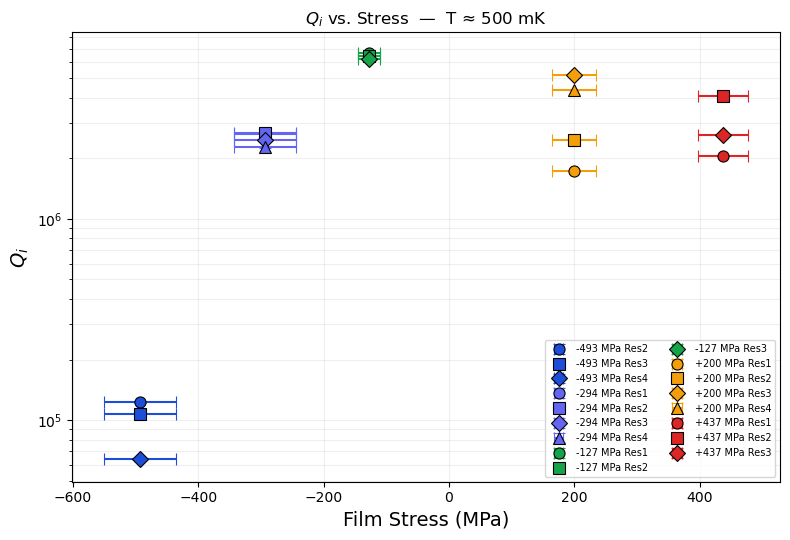

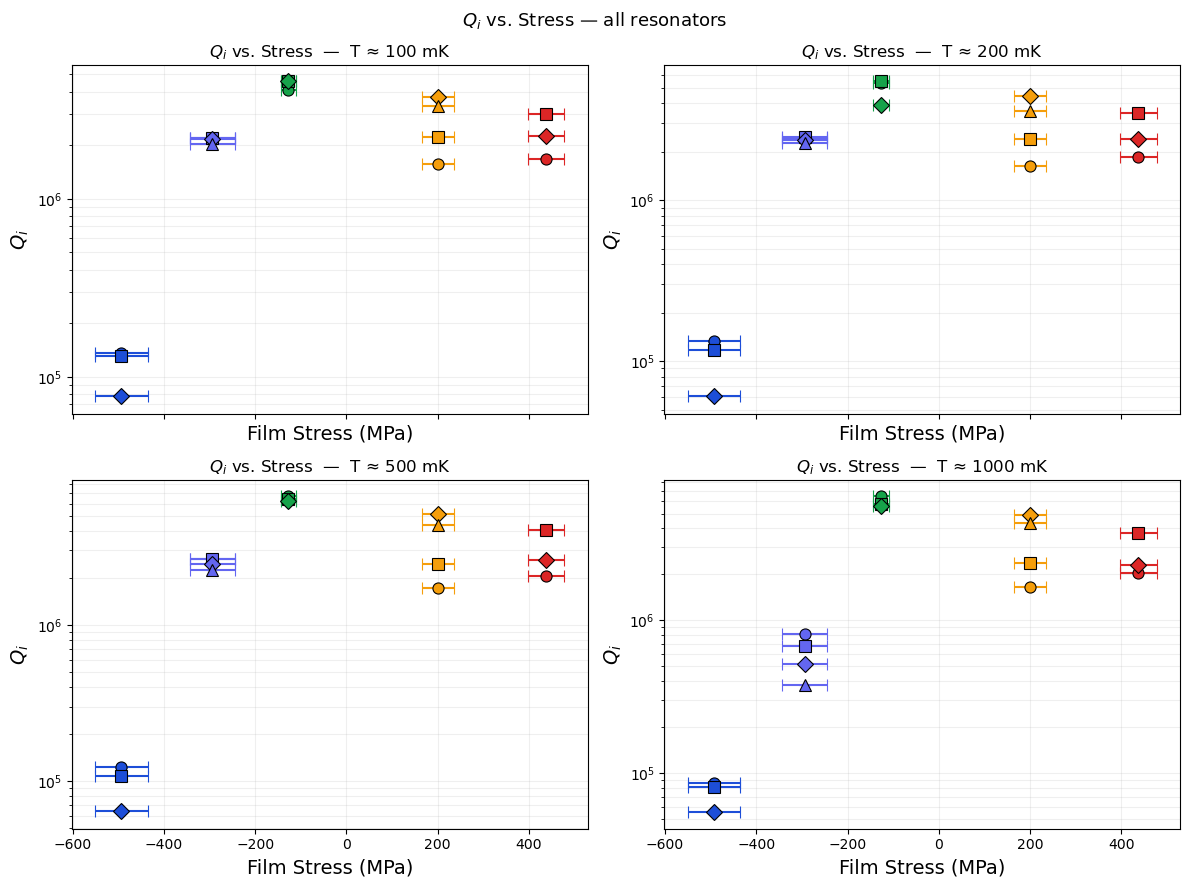

In [2]:
def ExtractAtTemps(Qi_arr, QiErr_arr, Temp_arr, select_temps, temp_tol=50):
    """
    Extract Qi, QiErr, and Temp at selected temperature points
    for a SINGLE resonator. Returns matched arrays.
    """
    select_temps = np.asarray(select_temps)
    mask = np.any(np.abs(Temp_arr[:, None] - select_temps[None, :]) <= temp_tol, axis=1)
    return Qi_arr[mask], QiErr_arr[mask], Temp_arr[mask]


temps_to_keep = [100, 200, 500, 1000]

# Dictionary: stress -> list of (label, Qi, QiErr, Temp) per resonator
stress_resonators = {
    -493: [
        ("Res2", SU_Nb_2mTorrRes2_Qi, SU_Nb_2mTorrRes2_QiErr, SU_Nb_2mTorrRes2_Temp),
        ("Res3", SU_Nb_2mTorrRes3_Qi, SU_Nb_2mTorrRes3_QiErr, SU_Nb_2mTorrRes3_Temp),
        ("Res4", SU_Nb_2mTorrRes4_Qi, SU_Nb_2mTorrRes4_QiErr, SU_Nb_2mTorrRes4_Temp),
    ],
    -294: [
        ("Res1", SU_Nb_ADR1_NoHFDipRes1_Qi, SU_Nb_ADR1_NoHFDipRes1_QiErr, SU_Nb_ADR1_NoHFDipRes1_Temp),
        ("Res2", SU_Nb_ADR1_NoHFDipRes2_Qi, SU_Nb_ADR1_NoHFDipRes2_QiErr, SU_Nb_ADR1_NoHFDipRes2_Temp),
        ("Res3", SU_Nb_ADR1_NoHFDipRes3_Qi, SU_Nb_ADR1_NoHFDipRes3_QiErr, SU_Nb_ADR1_NoHFDipRes3_Temp),
        ("Res4", SU_Nb_ADR1_NoHFDipRes4_Qi, SU_Nb_ADR1_NoHFDipRes4_QiErr, SU_Nb_ADR1_NoHFDipRes4_Temp),
    ],
    -127: [
        ("Res1", Qi_TempDep_40mm_SU_NbRes1_Qi, Qi_TempDep_40mm_SU_NbRes1_QiErr, Qi_TempDep_40mm_SU_NbRes1_Temp),
        ("Res2", Qi_TempDep_40mm_SU_NbRes2_Qi, Qi_TempDep_40mm_SU_NbRes2_QiErr, Qi_TempDep_40mm_SU_NbRes2_Temp),
        ("Res3", Qi_TempDep_40mm_SU_NbRes3_Qi, Qi_TempDep_40mm_SU_NbRes3_QiErr, Qi_TempDep_40mm_SU_NbRes3_Temp),
    ],
    200: [
        ("Res1", SU_Nb_10mTorrRes1_Qi, SU_Nb_10mTorrRes1_QiErr, SU_Nb_10mTorrRes1_Temp),
        ("Res2", SU_Nb_10mTorrRes2_Qi, SU_Nb_10mTorrRes2_QiErr, SU_Nb_10mTorrRes2_Temp),
        ("Res3", SU_Nb_10mTorrRes3_Qi, SU_Nb_10mTorrRes3_QiErr, SU_Nb_10mTorrRes3_Temp),
        ("Res4", SU_Nb_10mTorrRes4_Qi, SU_Nb_10mTorrRes4_QiErr, SU_Nb_10mTorrRes4_Temp),
    ],
    437: [
        ("Res1", CU_to_SU_WaferTradeRes1_Qi, CU_to_SU_WaferTradeRes1_QiErr, CU_to_SU_WaferTradeRes1_Temp),
        ("Res2", CU_to_SU_WaferTradeRes2_Qi, CU_to_SU_WaferTradeRes2_QiErr, CU_to_SU_WaferTradeRes2_Temp),
        ("Res3", CU_to_SU_WaferTradeRes3_Qi, CU_to_SU_WaferTradeRes3_QiErr, CU_to_SU_WaferTradeRes3_Temp),
    ],
}

stress_err = {-493: 57.2, -294: 49.4, -127: 17.4, 200: 35.0, 437: 40.0}

# Build flat arrays for fitting: one row per (resonator, temperature) pair
all_stress, all_T, all_Qi, all_QiErr, all_sErr, all_labels = [], [], [], [], [], []

for stress, res_list in stress_resonators.items():
    for label, Qi, QiErr, Temp in res_list:
        qi_sel, qierr_sel, t_sel = ExtractAtTemps(Qi, QiErr, Temp, temps_to_keep)
        for i in range(len(t_sel)):
            all_stress.append(float(stress))
            all_T.append(t_sel[i])         # mK
            all_Qi.append(qi_sel[i])
            all_QiErr.append(qierr_sel[i])
            all_sErr.append(stress_err[stress])
            all_labels.append(f"{stress} MPa {label}")

all_stress = np.array(all_stress)
all_T      = np.array(all_T)
all_Qi     = np.array(all_Qi)
all_QiErr  = np.array(all_QiErr)
all_sErr   = np.array(all_sErr)

print(f"Total data points: {len(all_Qi)}")
for stress in sorted(stress_resonators.keys()):
    mask = all_stress == stress
    n_res = len(stress_resonators[stress])
    n_pts = np.sum(mask)
    print(f"  σ = {stress:+d} MPa: {n_res} resonators, {n_pts} points")

def PlotQiVsStress_AllRes(stress_resonators, stress_err, target_temp, temp_tol=50, ax=None):
    """
    Plot Qi vs stress at a fixed temperature, showing every resonator
    as its own data point with measurement error bars.
    
    Parameters
    ----------
    stress_resonators : dict  — the dict built above
    stress_err        : dict  — {stress: ±MPa}
    target_temp       : float — target temperature in mK
    temp_tol          : float — tolerance for temperature matching (mK)
    ax                : matplotlib axis (created if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5))
    
    colors = {-493: '#1d4ed8', -294: '#6366f1', -127: '#16a34a',
              200: '#f59e0b', 437: '#dc2626'}
    markers = ['o', 's', 'D', '^']  # cycle per resonator within a stress

    for stress in sorted(stress_resonators.keys()):
        res_list = stress_resonators[stress]
        for j, (label, Qi, QiErr, Temp) in enumerate(res_list):
            diff = np.abs(Temp - target_temp)
            idx = diff.argmin()
            if diff[idx] > temp_tol:
                continue
            ax.errorbar(
                stress, Qi[idx], yerr=QiErr[idx], xerr=stress_err[stress],
                fmt=markers[j % len(markers)], color=colors[stress],
                ms=8, mec='k', mew=0.8, capsize=4, elinewidth=1.5,
                zorder=5, label=f'{stress:+d} MPa {label}'
            )

    ax.set_yscale('log')
    ax.set_xlabel('Film Stress (MPa)', fontsize=14)
    ax.set_ylabel(r'$Q_i$', fontsize=14)
    ax.set_title(f'$Q_i$ vs. Stress  —  T ≈ {target_temp:.0f} mK', fontsize=12)
    ax.grid(True, which='both', alpha=0.2)
    ax.legend(fontsize=7, ncol=2, loc='best')
    return ax


# ── Single temperature ──
fig, ax = plt.subplots(figsize=(8, 5.5))
PlotQiVsStress_AllRes(stress_resonators, stress_err, target_temp=500, ax=ax)
plt.tight_layout()
plt.show()

# ── Or panel all four temperatures at once ──
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for ax, T_target in zip(axes.flat, [100, 200, 500, 1000]):
    PlotQiVsStress_AllRes(stress_resonators, stress_err, T_target, ax=ax)
    ax.legend().remove()  # clean up per-panel legends
fig.suptitle('$Q_i$ vs. Stress — all resonators', fontsize=13)
fig.tight_layout()
plt.show()


Global fit: 17 resonators
  [ 0] σ=-493 MPa  Res2    (10 pts) (no TLS)
  [ 1] σ=-493 MPa  Res3    (10 pts) (no TLS)
  [ 2] σ=-493 MPa  Res4    (10 pts) (no TLS)
  [ 3] σ=-294 MPa  Res1    (11 pts) 
  [ 4] σ=-294 MPa  Res2    (11 pts) 
  [ 5] σ=-294 MPa  Res3    (11 pts) 
  [ 6] σ=-294 MPa  Res4    (11 pts) 
  [ 7] σ=-127 MPa  Res1    (11 pts) 
  [ 8] σ=-127 MPa  Res2    (11 pts) 
  [ 9] σ=-127 MPa  Res3    (11 pts) 
  [10] σ=+200 MPa  Res1    (10 pts) 
  [11] σ=+200 MPa  Res2    (10 pts) 
  [12] σ=+200 MPa  Res3    (10 pts) 
  [13] σ=+200 MPa  Res4    (10 pts) 
  [14] σ=+437 MPa  Res1    (11 pts) 
  [15] σ=+437 MPa  Res2    (11 pts) 
  [16] σ=+437 MPa  Res3    (11 pts) 
Total data points: 180  (150 with TLS, 30 without)
Params: 7 shared + 17 Q_other = 24
Fixed: f_min = 0.0

  Phase 1: DE on 7 shared params (Q_other fixed)
  TLS excluded for σ = -493 MPa
  μ bounded [1, 2],  f_min = 0.0 (fixed)
  Phase 1: χ²_red = 1.384  (293 generations)

  Phase 2: L-BFGS-B (24 params) …
  Phase 2: χ

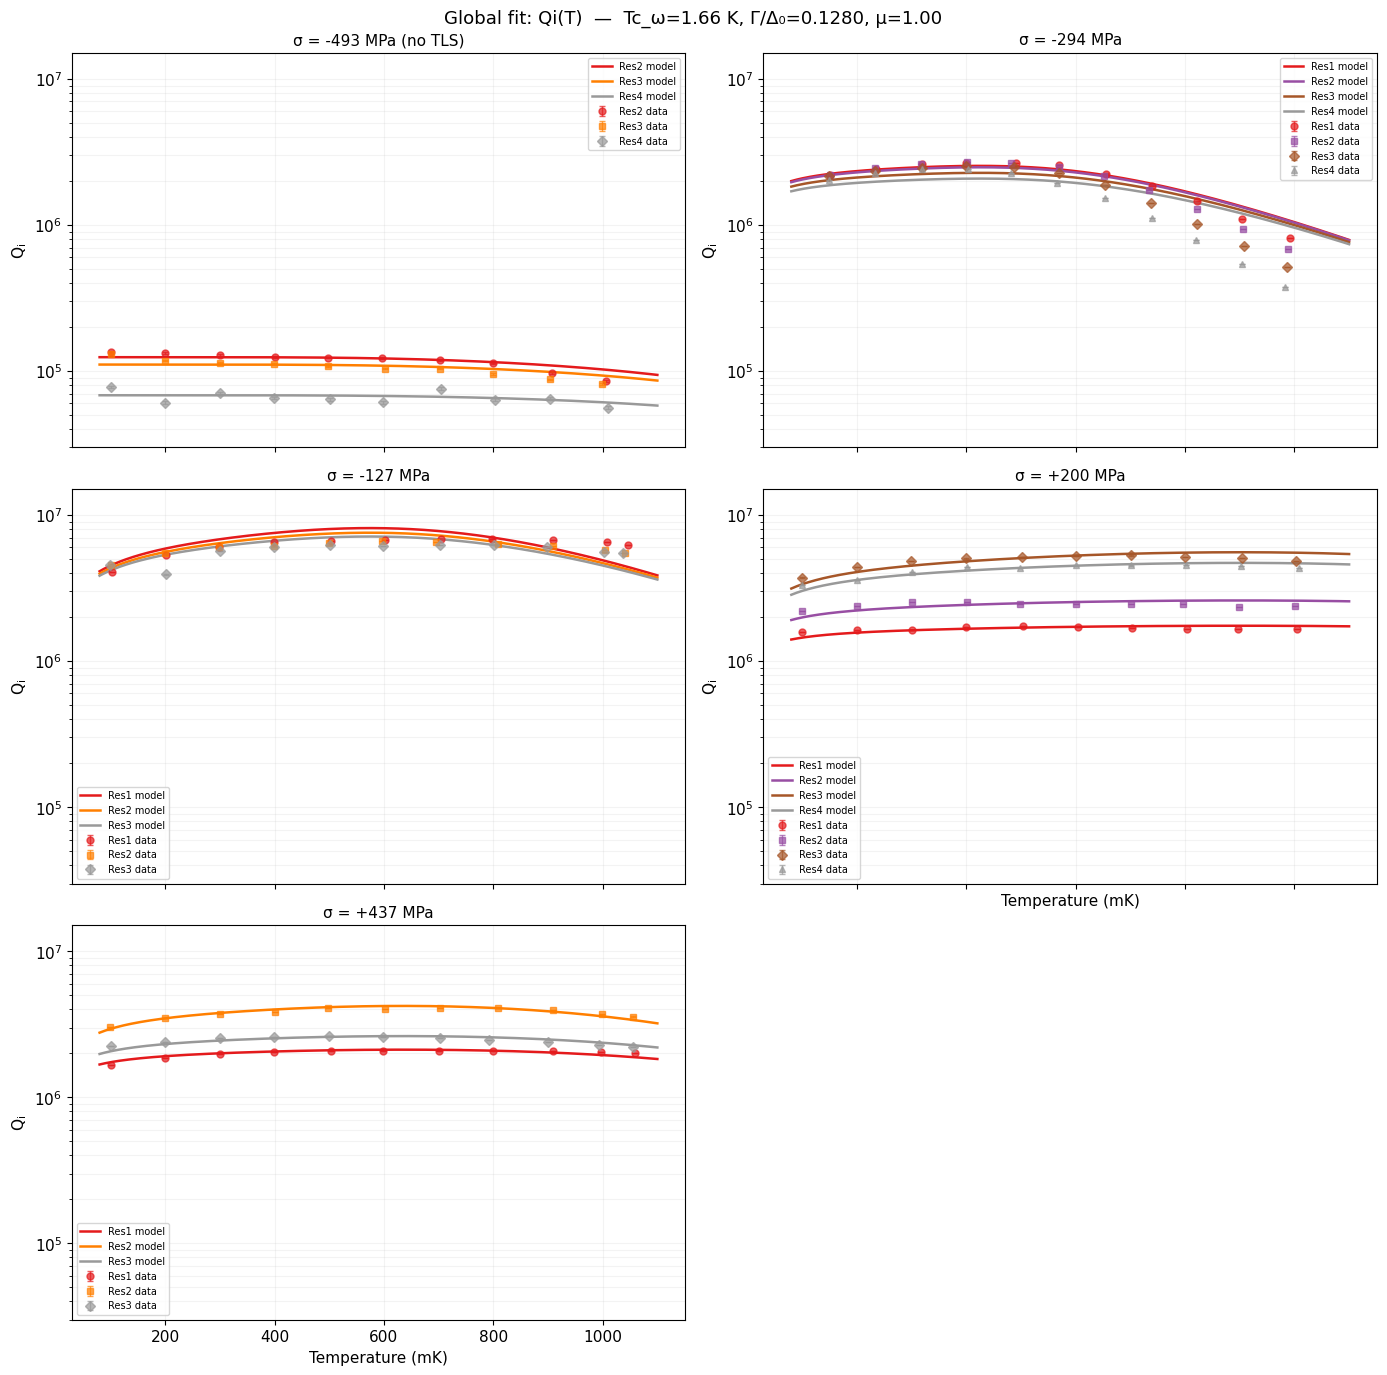

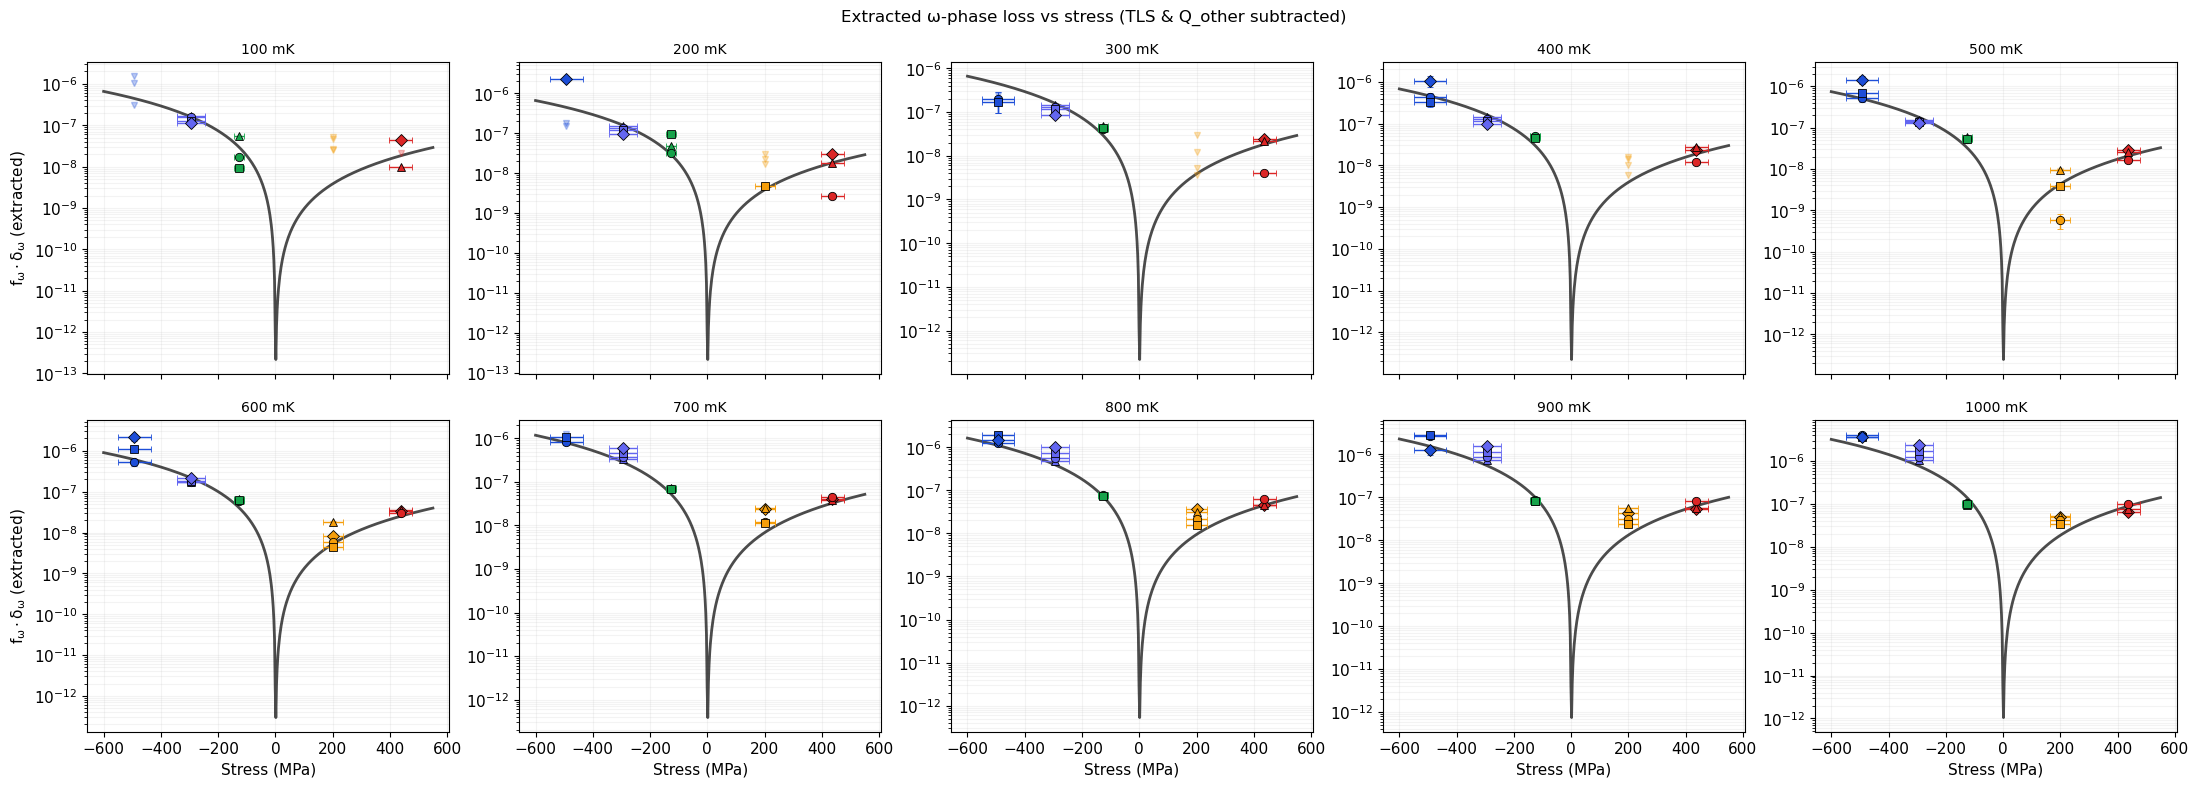

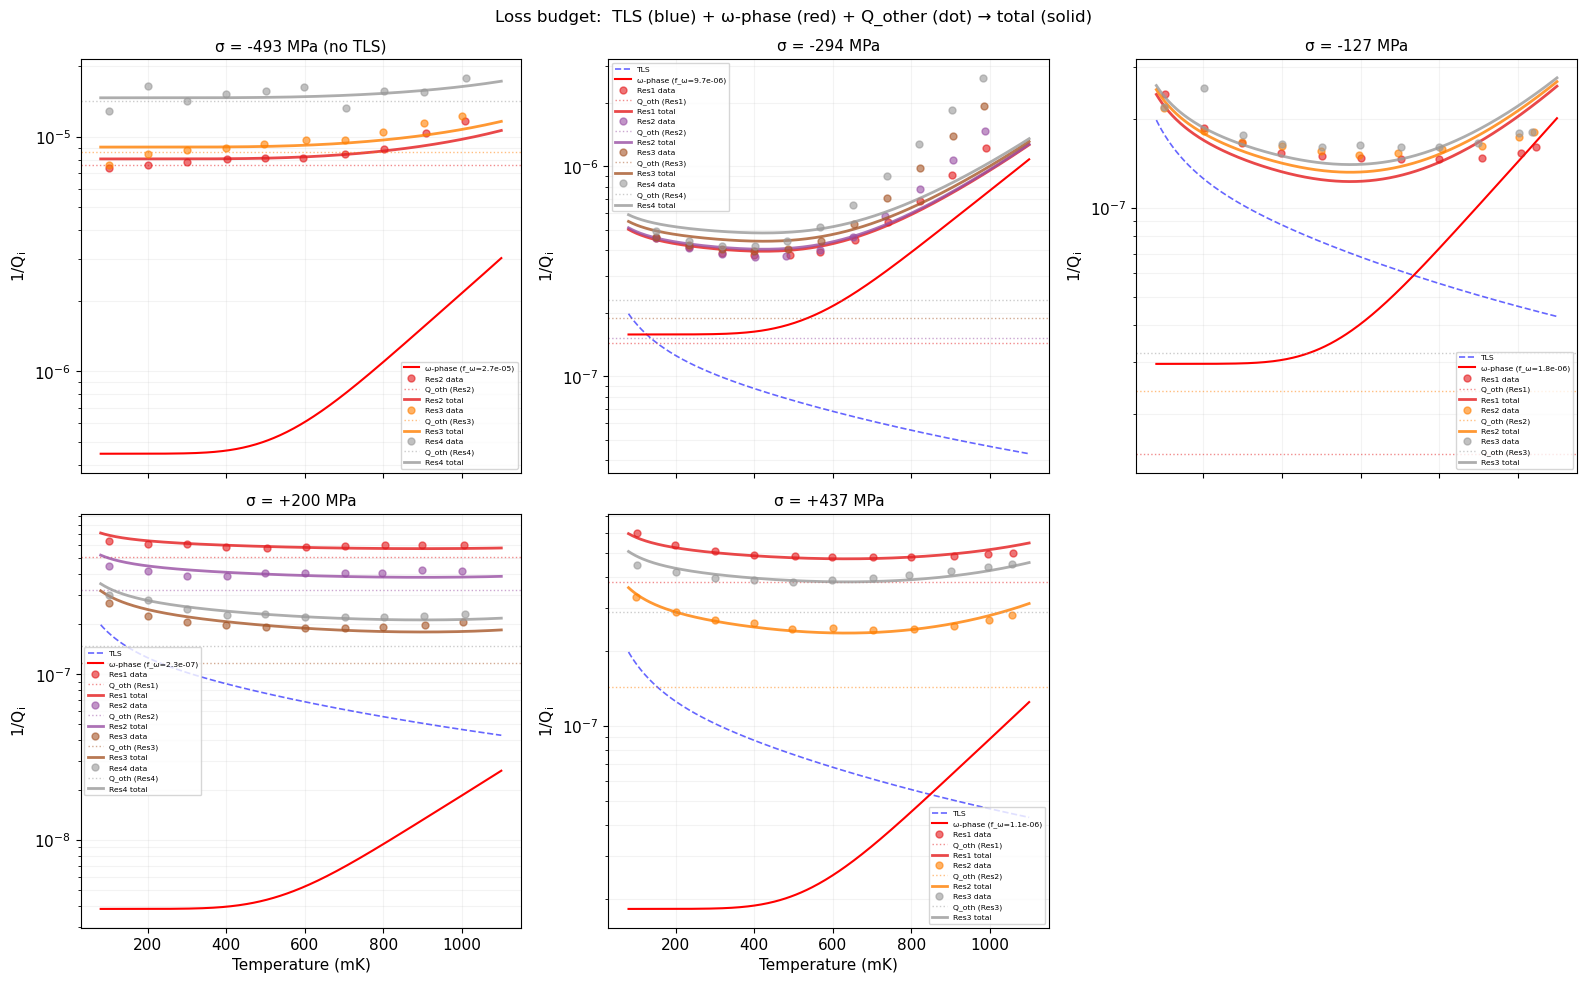

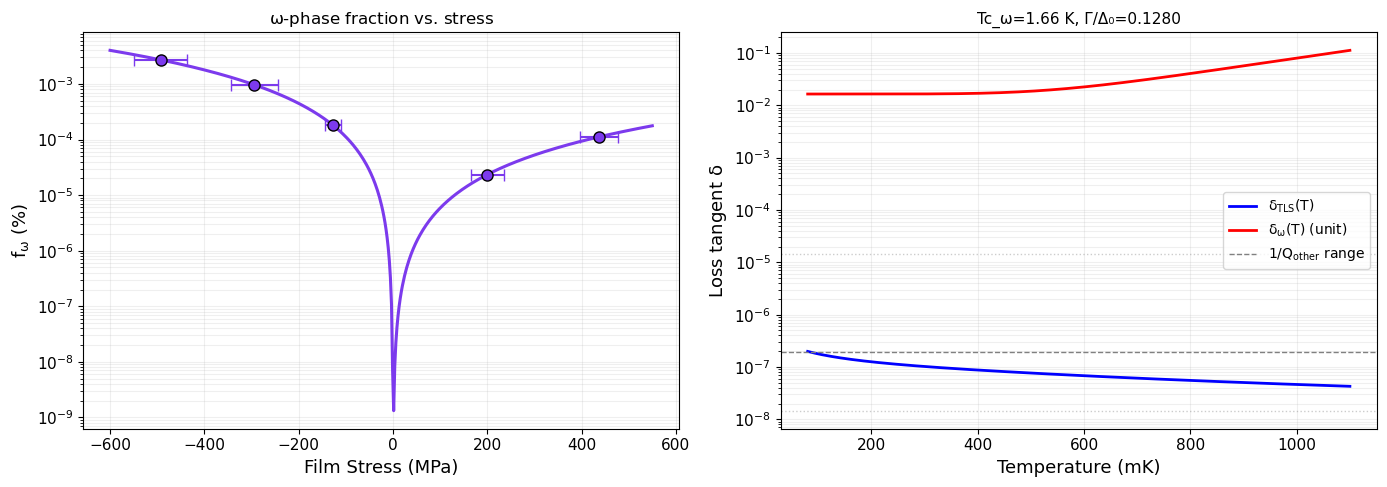

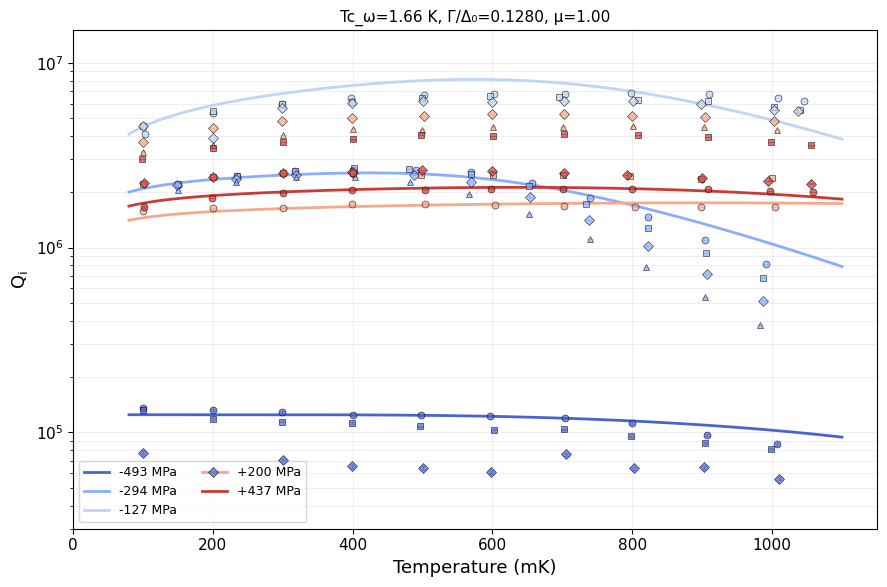

In [15]:
#!/usr/bin/env python3
"""
Single-stage global Qi(σ, T) model for Nb resonators.

  1/Qi(σ, T, res_j) = δ_TLS(T) · mask_j + f_ω(σ) · δ_ω(T; Tc_ω, Γ/Δ₀) + 1/Q_other_j

TLS is included for all resonators EXCEPT σ = -493 MPa, where ω-phase
loss dominates so completely that TLS is undetectable and would only
add noise to the shared TLS parameter estimates.

Fixed parameters:
  μ     = 1.5   (TLS relaxation exponent — standard one-phonon + dephasing)
  f_min = 0     (no ω-phase at zero stress — hit bound in all prior fits)

Shared free parameters (6):
  δ_TLS0, C_sat          — TLS (stress-independent, surface/interface)
  Tc_ω, Γ/Δ₀, α_c, α_t  — ω-phase effective medium

Per-resonator free parameters (N_res):
  Q_other_j  — coupling, radiation, geometry (T-independent)

Optimization:
  Phase 1: DE on 6 shared params (Q_other fixed from data)
  Phase 2: L-BFGS-B refinement of all 6+N_res params
"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import special
from scipy.optimize import differential_evolution, minimize
matplotlib.rcParams.update({'font.size': 11, 'mathtext.default': 'regular'})

# ── Constants ───────────────────────────────────────────────────────
hbar_SI = 6.626070e-34
Kb      = 1.380649e-23
SIGMA_OPT = 0.0

# Fixed parameters
FMIN_FIXED = 0.0   # ω-phase fraction at zero stress

# Stress to EXCLUDE from TLS channel
TLS_EXCLUDE_STRESS = -493  # MPa

temps_to_keep = np.linspace(100, 1000, 10)
T_FIT_MAX = 1100
FRAC_ERROR_FLOOR = 0.15

# ── Paste your stress_resonators dict and stress_err dict here ──
# stress_resonators = { -493: [...], -294: [...], ... }
# stress_err = {-493: 57.2, -294: 49.4, -127: 17.4, 200: 35.0, 437: 40.0}


# ═════════════════════════════════════════════════════════════════════
#  DATA EXTRACTION
# ═════════════════════════════════════════════════════════════════════

def ExtractAtTemps(Qi_arr, QiErr_arr, Temp_arr, select_temps, temp_tol=50):
    select_temps = np.asarray(select_temps)
    mask = np.any(np.abs(Temp_arr[:, None] - select_temps[None, :]) <= temp_tol, axis=1)
    return Qi_arr[mask], QiErr_arr[mask], Temp_arr[mask]


# ═════════════════════════════════════════════════════════════════════
#  VECTORIZED PHYSICS
# ═════════════════════════════════════════════════════════════════════

def tls_loss_vec(T_mK, delta_TLS0, C_sat, mu, f_res=5.5e9):
    """TLS loss — vectorized."""
    T = np.asarray(T_mK, dtype=float) * 1e-3
    x = np.clip(hbar_SI * 2 * np.pi * f_res / (2 * Kb * T), 1e-10, 500)
    th = np.tanh(x)
    return delta_TLS0 * th / np.sqrt(1.0 + C_sat * T**mu * th)


def omega_frac_vec(stress, alpha_c, alpha_t):
    """ω-phase volume fraction with f_min = 0, σ_opt = 0."""
    ds = np.asarray(stress, dtype=float) - SIGMA_OPT
    f = np.where(ds < 0,
                 alpha_c * ds**2,
                 alpha_t * ds**2)
    return np.clip(f, 0.0, 1.0)


def mb_loss_omega_vec(T_mK, Tc_omega, Gamma_ratio, f_res=5.5e9):
    """Dynes-broadened Mattis-Bardeen loss δ_ω(T) — vectorized."""
    T = np.asarray(T_mK, dtype=float) * 1e-3
    Delta0 = 1.764 * Kb * Tc_omega
    hw = hbar_SI * 2 * np.pi * f_res
    Gamma = Gamma_ratio * Delta0

    ratio = np.where(T > 0, Tc_omega / T, np.inf)
    D = np.where(ratio > 1.0,
                 Delta0 * np.tanh(1.74 * np.sqrt(np.clip(ratio - 1.0, 0, None))),
                 0.0)

    D_safe = np.where(D > 0, D, 1.0)

    # Dynes residual subgap loss
    loss_dynes = np.where(D > 0, (Gamma / D_safe)**2,
                          1.0 / max(Gamma_ratio, 1e-6))

    # Thermal QP loss
    dkt = np.where(D > 0, D_safe / (Kb * T), 700.0)
    x_arg = np.clip(hw / (2 * Kb * T), 1e-10, 500)
    thermal_ok = (D > 0) & (dkt < 500)
    loss_th = np.zeros_like(T)
    if np.any(thermal_ok):
        m = thermal_ok
        loss_th[m] = (4.0 / np.pi) * np.exp(-dkt[m]) * np.sinh(x_arg[m]) * special.k0(x_arg[m])

    denom = np.where(D > 0, np.tanh(np.clip(D_safe / (2 * Kb * T), 1e-10, 500)), 1e-30)
    return (loss_dynes + loss_th) / np.maximum(denom, 1e-30)


# ═════════════════════════════════════════════════════════════════════
#  BUILD GLOBAL DATASET
# ═════════════════════════════════════════════════════════════════════

resonator_catalog = []
data_blocks = []

for stress in sorted(stress_resonators.keys()):
    for label, Qi_full, QiErr_full, Temp_full in stress_resonators[stress]:
        f_res = 5.5e9
        qi_sel, qierr_sel, t_sel = ExtractAtTemps(
            Qi_full, QiErr_full, Temp_full, temps_to_keep, temp_tol=60)
        if len(t_sel) < 3:
            print(f"  Skip {stress:+d} MPa {label}: only {len(t_sel)} pts")
            continue
        resonator_catalog.append((stress, label, f_res))
        data_blocks.append((t_sel, qi_sel, qierr_sel))

N_RES = len(resonator_catalog)
print(f"\nGlobal fit: {N_RES} resonators")
for j, (s, lbl, f) in enumerate(resonator_catalog):
    tls_tag = '(no TLS)' if s == TLS_EXCLUDE_STRESS else ''
    print(f"  [{j:2d}] σ={s:+d} MPa  {lbl:6s}  ({len(data_blocks[j][0])} pts) {tls_tag}")

# Flatten into parallel arrays
flat_j = []
flat_s = []
flat_T = []
flat_loss = []
flat_lerr = []

for j in range(N_RES):
    T_a, Qi_a, Err_a = data_blocks[j]
    n = len(T_a)
    flat_j.extend([j] * n)
    flat_s.extend([float(resonator_catalog[j][0])] * n)
    flat_T.extend(T_a.tolist())
    flat_loss.extend((1.0 / Qi_a).tolist())
    flat_lerr.extend((Err_a / Qi_a**2).tolist())

flat_j    = np.array(flat_j, dtype=int)
flat_s    = np.array(flat_s)
flat_T    = np.array(flat_T)
flat_loss = np.array(flat_loss)
flat_lerr = np.array(flat_lerr)
N_DATA = len(flat_loss)

# TLS mask: 1.0 for resonators that include TLS, 0.0 for excluded
flat_tls_mask = np.where(flat_s == TLS_EXCLUDE_STRESS, 0.0, 1.0)

# Systematic error floor
flat_lerr_eff = np.sqrt(flat_lerr**2 + (FRAC_ERROR_FLOOR * flat_loss)**2)

# Q_other init from data peaks
Q_other_init = np.array([np.max(data_blocks[j][1]) for j in range(N_RES)])
log_Q_init = np.log10(Q_other_init)

n_tls = int(np.sum(flat_tls_mask > 0))
n_notls = N_DATA - n_tls
print(f"Total data points: {N_DATA}  ({n_tls} with TLS, {n_notls} without)")
print(f"Params: 7 shared + {N_RES} Q_other = {7 + N_RES}")
print(f"Fixed: f_min = {FMIN_FIXED}")


# ═════════════════════════════════════════════════════════════════════
#  VECTORIZED COST FUNCTIONS
# ═════════════════════════════════════════════════════════════════════

N_SHARED = 7

#  Parameter vector:
#    x[0] = log10(δ_TLS0)
#    x[1] = log10(C_sat)
#    x[2] = μ               — linear, bounded [1, 2]
#    x[3] = Tc_ω  (K)       — linear
#    x[4] = log10(Γ/Δ₀)
#    x[5] = log10(α_c)
#    x[6] = log10(α_t)
#    x[7:] = log10(Q_other_j)

def _model_loss(x_sh, log_Qo):
    """Model 1/Qi — vectorized. TLS masked out for excluded stress."""
    delta_TLS0  = 10**x_sh[0]
    C_sat       = 10**x_sh[1]
    mu          = x_sh[2]
    Tc_omega    = x_sh[3]
    Gamma_ratio = 10**x_sh[4]
    alpha_c     = 10**x_sh[5]
    alpha_t     = 10**x_sh[6]

    d_tls = tls_loss_vec(flat_T, delta_TLS0, C_sat, mu) * flat_tls_mask

    f_w = omega_frac_vec(flat_s, alpha_c, alpha_t)
    d_w = mb_loss_omega_vec(flat_T, Tc_omega, Gamma_ratio)

    d_oth = 1.0 / (10**log_Qo[flat_j])

    return d_tls + f_w * d_w + d_oth


def _chi2(x_sh, log_Qo):
    resid = (flat_loss - _model_loss(x_sh, log_Qo)) / flat_lerr_eff
    return np.sum(resid**2) / N_DATA


def cost_phase1(x_sh):
    return _chi2(x_sh, log_Q_init)


def cost_phase2(x_all):
    return _chi2(x_all[:N_SHARED], x_all[N_SHARED:])


# ═════════════════════════════════════════════════════════════════════
#  PHASE 1: DE on 7 shared params
# ═════════════════════════════════════════════════════════════════════

bounds_shared = [
    (-8,  -3),      # log10(δ_TLS0)
    (-2,   8),      # log10(C_sat)
    (1.0,  2.0),    # μ
    (0.5,  8.0),    # Tc_ω  (K)
    (-6,  -0.001),  # log10(Γ/Δ₀)
    (-14,  0),      # log10(α_c)
    (-14, -5),      # log10(α_t)
]

print("\n" + "=" * 70)
print(f"  Phase 1: DE on {N_SHARED} shared params (Q_other fixed)")
print(f"  TLS excluded for σ = {TLS_EXCLUDE_STRESS} MPa")
print(f"  μ bounded [1, 2],  f_min = {FMIN_FIXED} (fixed)")
print("=" * 70)

res1 = differential_evolution(
    cost_phase1, bounds_shared,
    seed=42, maxiter=2000, tol=1e-10,
    mutation=(0.5, 1.5), recombination=0.9,
    popsize=30, polish=True,
)
print(f"  Phase 1: χ²_red = {res1.fun:.3f}  ({res1.nit} generations)")


# ═════════════════════════════════════════════════════════════════════
#  PHASE 2: L-BFGS-B on all 6 + N_RES params
# ═════════════════════════════════════════════════════════════════════

x0_full = np.concatenate([res1.x, log_Q_init])

bounds_Qo = [(np.log10(np.min(data_blocks[j][1]) * 0.1),
              np.log10(np.max(data_blocks[j][1]) * 10.0))
             for j in range(N_RES)]
bounds_all = bounds_shared + bounds_Qo

print(f"\n  Phase 2: L-BFGS-B ({N_SHARED + N_RES} params) …")

res2 = minimize(
    cost_phase2, x0_full, method='L-BFGS-B',
    bounds=bounds_all,
    options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-10},
)
print(f"  Phase 2: χ²_red = {res2.fun:.3f}  "
      f"({'converged' if res2.success else res2.message})")


# ═════════════════════════════════════════════════════════════════════
#  UNPACK RESULTS
# ═════════════════════════════════════════════════════════════════════

xf = res2.x
g_delta_TLS0  = 10**xf[0]
g_C_sat       = 10**xf[1]
g_mu          = xf[2]
g_Tc_omega    = xf[3]
g_Gamma_ratio = 10**xf[4]
g_alpha_c     = 10**xf[5]
g_alpha_t     = 10**xf[6]
g_Q_other     = 10**xf[N_SHARED:]

g_Delta0_w = 1.764 * Kb * g_Tc_omega
g_Gamma    = g_Gamma_ratio * g_Delta0_w

print(f"\n  ── Final results  (reduced χ² = {res2.fun:.3f}) ──")
print(f"\n  TLS (shared, excl. {TLS_EXCLUDE_STRESS} MPa):")
print(f"    δ_TLS0     = {g_delta_TLS0:.3e}")
print(f"    C_sat      = {g_C_sat:.3e}")
print(f"    μ          = {g_mu:.3f}")
print(f"\n  ω-phase (shared, f_min=0 fixed):")
print(f"    Tc(ω)      = {g_Tc_omega:.3f} K")
print(f"    Γ/Δ₀       = {g_Gamma_ratio:.4f}")
print(f"    Γ          = {g_Gamma / 1.602e-19 * 1e6:.2f} µeV")
print(f"    Δ₀(ω)      = {g_Delta0_w / 1.602e-19 * 1e3:.4f} meV")
print(f"    α_c        = {g_alpha_c:.3e} MPa⁻²")
print(f"    α_t        = {g_alpha_t:.3e} MPa⁻²")
print(f"    α_c/α_t    = {g_alpha_c / max(g_alpha_t, 1e-30):.1f}")
print(f"\n  Per-resonator Q_other:")
for j in range(N_RES):
    s, lbl, _ = resonator_catalog[j]
    tls_tag = '(no TLS)' if s == TLS_EXCLUDE_STRESS else ''
    print(f"    [{j:2d}] {s:+d} MPa {lbl:6s}:  Q_other = {g_Q_other[j]:.3e} {tls_tag}")


# ═════════════════════════════════════════════════════════════════════
#  PLOT HELPERS
# ═════════════════════════════════════════════════════════════════════

def model_Qi_curve(T_mK_arr, stress, res_idx, f_res=5.5e9):
    """Full model Qi(T) for one resonator."""
    T_a = np.atleast_1d(T_mK_arr)
    # TLS included only if not excluded stress
    if resonator_catalog[res_idx][0] == TLS_EXCLUDE_STRESS:
        d_tls = 0.0
    else:
        d_tls = tls_loss_vec(T_a, g_delta_TLS0, g_C_sat, g_mu, f_res)
    f_w = omega_frac_vec(float(stress), g_alpha_c, g_alpha_t)
    d_w = mb_loss_omega_vec(T_a, g_Tc_omega, g_Gamma_ratio, f_res)
    return 1.0 / (d_tls + f_w * d_w + 1.0 / g_Q_other[res_idx])


def model_components(T_mK_arr, stress, res_idx, f_res=5.5e9):
    """Return (δ_TLS, f_ω·δ_ω, 1/Q_other, δ_total) arrays."""
    T_a = np.atleast_1d(T_mK_arr)
    if resonator_catalog[res_idx][0] == TLS_EXCLUDE_STRESS:
        d_tls = np.zeros_like(T_a)
    else:
        d_tls = tls_loss_vec(T_a, g_delta_TLS0, g_C_sat, g_mu, f_res)
    f_w = omega_frac_vec(float(stress), g_alpha_c, g_alpha_t)
    d_w = f_w * mb_loss_omega_vec(T_a, g_Tc_omega, g_Gamma_ratio, f_res)
    d_o = 1.0 / g_Q_other[res_idx]
    return d_tls, d_w, d_o, d_tls + d_w + d_o


# ═════════════════════════════════════════════════════════════════════
#  PLOT 1: Qi(T) per stress panel
# ═════════════════════════════════════════════════════════════════════

T_mod = np.linspace(80, 1100, 300)
stress_list = sorted(stress_resonators.keys())
mkrs = ['o', 's', 'D', '^']

fig1, ax1 = plt.subplots(3, 2, figsize=(14, 14), sharex=True)
ax1f = ax1.flat

for pi, stress in enumerate(stress_list):
    ax = ax1f[pi]
    rr = [(j, resonator_catalog[j]) for j in range(N_RES) if resonator_catalog[j][0] == stress]

    for k, (j, (s, lbl, fr)) in enumerate(rr):
        c = plt.cm.Set1(k / max(len(rr) - 1, 1))
        Td, Qd, Ed = data_blocks[j]
        ax.errorbar(Td, Qd, yerr=Ed, fmt=mkrs[k % 4], color=c, ms=5,
                    capsize=2, elinewidth=1, alpha=0.7, label=f'{lbl} data')
        ax.plot(T_mod, model_Qi_curve(T_mod, stress, j, fr), '-', color=c, lw=1.8,
                label=f'{lbl} model')

    tls_note = ' (no TLS)' if stress == TLS_EXCLUDE_STRESS else ''
    ax.set_yscale('log'); ax.set_ylabel(r'$Q_i$')
    ax.set_title(f'σ = {stress:+d} MPa{tls_note}', fontsize=11)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, which='both', alpha=0.15)
    ax.set_ylim(3e4, 1.5e7)

if len(stress_list) < 6: ax1f[5].set_visible(False)
ax1f[4].set_xlabel('Temperature (mK)'); ax1f[3].set_xlabel('Temperature (mK)')
fig1.suptitle(f'Global fit: Qi(T)  —  Tc_ω={g_Tc_omega:.2f} K, '
              f'Γ/Δ₀={g_Gamma_ratio:.4f}, μ={g_mu:.2f}',
              fontsize=13)
fig1.tight_layout(); plt.show()


# ═════════════════════════════════════════════════════════════════════
#  PLOT 2: Extracted ω-phase loss vs stress
# ═════════════════════════════════════════════════════════════════════

stress_dense = np.linspace(-600, 550, 500)
cs = {-493: '#1d4ed8', -294: '#6366f1', -127: '#16a34a', 200: '#f59e0b', 437: '#dc2626'}

fig2, ax2 = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
for i, Tt in enumerate(temps_to_keep):
    r, ci = divmod(i, 5)
    ax = ax2[r, ci]

    # Model curve
    d_w_T = mb_loss_omega_vec(np.array([Tt]), g_Tc_omega, g_Gamma_ratio)[0]
    fw_dense = omega_frac_vec(stress_dense, g_alpha_c, g_alpha_t)
    ax.semilogy(stress_dense, fw_dense * d_w_T, '-k', lw=2, alpha=0.7)

    # Extracted: 1/Qi - δ_TLS - 1/Q_other
    for j in range(N_RES):
        s, lbl, fr = resonator_catalog[j]
        Td, Qd, Ed = data_blocks[j]
        idx = np.argmin(np.abs(Td - Tt))
        if np.abs(Td[idx] - Tt) > 60: continue

        d_data = 1.0 / Qd[idx]
        if s == TLS_EXCLUDE_STRESS:
            d_tls_pt = 0.0
        else:
            d_tls_pt = tls_loss_vec(np.array([Td[idx]]), g_delta_TLS0, g_C_sat, g_mu)[0]
        d_other_j = 1.0 / g_Q_other[j]
        d_omega_ext = d_data - d_tls_pt - d_other_j
        d_omega_err = Ed[idx] / Qd[idx]**2

        if d_omega_ext > 0:
            ax.errorbar(s, d_omega_ext, yerr=d_omega_err,
                        xerr=stress_err.get(s, 0),
                        fmt=mkrs[j % 4], color=cs.get(s, 'gray'),
                        ms=6, mec='k', mew=0.6, capsize=2, elinewidth=1, zorder=5)
        else:
            ax.plot(s, abs(d_omega_ext) + d_omega_err, 'v',
                    color=cs.get(s, 'gray'), ms=4, alpha=0.3)

    ax.set_title(f'{Tt:.0f} mK', fontsize=10)
    ax.grid(True, which='both', alpha=0.15)
    if ci == 0: ax.set_ylabel(r'$f_\omega \cdot \delta_\omega$ (extracted)')
    if r == 1: ax.set_xlabel('Stress (MPa)')

fig2.suptitle('Extracted ω-phase loss vs stress (TLS & Q_other subtracted)', fontsize=12)
fig2.tight_layout(); plt.show()


# ═════════════════════════════════════════════════════════════════════
#  PLOT 3: Loss budget per stress
# ═════════════════════════════════════════════════════════════════════

Tb = np.linspace(80, 1100, 300)
fig3, ax3 = plt.subplots(2, 3, figsize=(16, 10), sharex=True)
ax3f = ax3.flat

for pi, stress in enumerate(stress_list):
    ax = ax3f[pi]
    rr = [(j, resonator_catalog[j]) for j in range(N_RES) if resonator_catalog[j][0] == stress]
    if not rr: continue

    d_tls, d_w, _, _ = model_components(Tb, stress, rr[0][0])
    fw_val = float(omega_frac_vec(float(stress), g_alpha_c, g_alpha_t))

    if stress != TLS_EXCLUDE_STRESS:
        ax.semilogy(Tb, d_tls, '--b', lw=1.2, alpha=0.6, label='TLS')
    ax.semilogy(Tb, d_w, '-r', lw=1.5, label=f'ω-phase (f_ω={fw_val:.1e})')

    for k, (j, (s, lbl, fr)) in enumerate(rr):
        c = plt.cm.Set1(k / max(len(rr) - 1, 1))
        Td, Qd, Ed = data_blocks[j]
        ax.semilogy(Td, 1.0 / Qd, 'o', color=c, ms=5, alpha=0.6, label=f'{lbl} data')
        d_o = 1.0 / g_Q_other[j]
        ax.axhline(d_o, color=c, ls=':', lw=1, alpha=0.5, label=f'Q_oth ({lbl})')
        _, d_w_j, d_o_j, d_tot_j = model_components(Tb, stress, j)
        ax.semilogy(Tb, d_tot_j, '-', color=c, lw=2, alpha=0.8, label=f'{lbl} total')

    tls_note = ' (no TLS)' if stress == TLS_EXCLUDE_STRESS else ''
    ax.set_title(f'σ = {stress:+d} MPa{tls_note}', fontsize=11)
    ax.set_ylabel(r'$1/Q_i$'); ax.legend(fontsize=5.5, loc='best')
    ax.grid(True, which='both', alpha=0.15)

if len(stress_list) < 6: ax3f[5].set_visible(False)
ax3f[4].set_xlabel('Temperature (mK)'); ax3f[3].set_xlabel('Temperature (mK)')
fig3.suptitle('Loss budget:  TLS (blue) + ω-phase (red) + Q_other (dot) → total (solid)',
              fontsize=12)
fig3.tight_layout(); plt.show()


# ═════════════════════════════════════════════════════════════════════
#  PLOT 4: ω-fraction and loss channels
# ═════════════════════════════════════════════════════════════════════

fig4, (axf, axl) = plt.subplots(1, 2, figsize=(14, 5))

fc = omega_frac_vec(stress_dense, g_alpha_c, g_alpha_t)
axf.semilogy(stress_dense, fc * 100, '-', color='#7c3aed', lw=2.2)
for st in stress_list:
    fw = float(omega_frac_vec(float(st), g_alpha_c, g_alpha_t))
    axf.errorbar(st, fw * 100, xerr=stress_err[st], fmt='o', color='#7c3aed',
                 ms=8, mec='k', mew=1, capsize=4, zorder=5)
axf.set_xlabel('Film Stress (MPa)', fontsize=13)
axf.set_ylabel(r'$f_\omega$ (%)', fontsize=13)
axf.set_title(r'$\omega$-phase fraction vs. stress', fontsize=12)
axf.grid(True, which='both', alpha=0.2)

Tl = np.linspace(80, 1100, 300)
axl.semilogy(Tl, tls_loss_vec(Tl, g_delta_TLS0, g_C_sat, g_mu),
             '-b', lw=2, label=r'$\delta_\mathrm{TLS}(T)$')
axl.semilogy(Tl, mb_loss_omega_vec(Tl, g_Tc_omega, g_Gamma_ratio),
             '-r', lw=2, label=r'$\delta_\omega(T)$ (unit)')

Qs = np.sort(g_Q_other)
axl.axhline(1.0 / Qs[0], color='gray', ls=':', lw=1, alpha=0.4)
axl.axhline(1.0 / Qs[N_RES // 2], color='gray', ls='--', lw=1,
             label=r'1/$Q_\mathrm{other}$ range')
axl.axhline(1.0 / Qs[-1], color='gray', ls=':', lw=1, alpha=0.4)
axl.set_xlabel('Temperature (mK)', fontsize=13)
axl.set_ylabel(r'Loss tangent $\delta$', fontsize=13)
axl.set_title(f'Tc_ω={g_Tc_omega:.2f} K, Γ/Δ₀={g_Gamma_ratio:.4f}', fontsize=11)
axl.legend(fontsize=10); axl.grid(True, which='both', alpha=0.2)

fig4.tight_layout(); plt.show()


# ═════════════════════════════════════════════════════════════════════
#  PLOT 5: All stresses on one panel
# ═════════════════════════════════════════════════════════════════════

fig5, ax5 = plt.subplots(figsize=(9, 6))
cmap = plt.cm.coolwarm
nm = matplotlib.colors.Normalize(vmin=-550, vmax=500)

for stress in stress_list:
    cc = cmap(nm(stress))
    rr = [(j, resonator_catalog[j]) for j in range(N_RES) if resonator_catalog[j][0] == stress]
    if rr:
        j0 = rr[0][0]
        ax5.semilogy(T_mod, model_Qi_curve(T_mod, stress, j0), '-', color=cc, lw=2,
                      label=f'{stress:+d} MPa')
    for k, (j, (s, lbl, fr)) in enumerate(rr):
        Td, Qd, Ed = data_blocks[j]
        ax5.errorbar(Td, Qd, yerr=Ed, fmt=mkrs[k % 4], color=cc, ms=5,
                      mec='k', mew=0.5, capsize=2, elinewidth=1, alpha=0.7, zorder=5)

ax5.set_xlabel('Temperature (mK)', fontsize=13)
ax5.set_ylabel(r'$Q_i$', fontsize=13)
ax5.set_title(f'Tc_ω={g_Tc_omega:.2f} K, '
              f'Γ/Δ₀={g_Gamma_ratio:.4f}, μ={g_mu:.2f}', fontsize=11)
ax5.legend(fontsize=9, ncol=2, loc='lower left')
ax5.set_ylim(3e4, 1.5e7); ax5.set_xlim(0, 1150)
ax5.grid(True, which='both', alpha=0.2)
fig5.tight_layout(); plt.show()